# Load

In [ ]:
import pandas as pd
import numpy as np
#!pip install hmmlearn

df = pd.read_csv("F-F_Research_Data_5_Factors_2x3_daily.csv", skiprows=4, skipfooter=2, engine="python")
df = df.rename(columns={df.columns[0]:"date"})
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")

df2 = pd.read_csv("F-F_Momentum_Factor_daily.csv", skiprows=13, skipfooter=2, engine="python")
df2 = df2.rename(columns={df2.columns[0]:"date"})
df2["date"] = pd.to_datetime(df2["date"], format="%Y%m%d")
ff6 = df.merge(df2, on="date", how="inner").dropna().set_index('date') #no null

FACTOR_COLS=["Mkt-RF","SMB","HML","RMW","CMA","Mom"]
display(ff6.describe())
ff6 = ff6#.tail(252*10)

,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom
count,15876.000000,15876.000000,15876.000000,15876.000000,15876.000000,15876.000000,15876.000000
mean,0.028974,0.006283,0.014948,0.012543,0.011963,0.017164,0.028744
std,1.021590,0.551083,0.587706,0.412699,0.385651,0.012677,0.789551
min,-17.440000,-11.150000,-5.030000,-2.960000,-5.300000,0.000000,-14.390000
25%,-0.420000,-0.280000,-0.240000,-0.180000,-0.180000,0.010000,-0.250000
50%,0.050000,0.020000,0.010000,0.010000,0.010000,0.020000,0.060000
75%,0.510000,0.310000,0.260000,0.190000,0.200000,0.020000,0.370000
max,11.360000,6.080000,6.730000,4.570000,2.470000,0.060000,7.120000


# Technical Analysis

TA. Daily factor returns are converted once to decimals and compounded into synthetic factor indices. Every individual parameterization produces a discrete \(-1,0,+1\) signal. Three parameterizations are equally averaged into each of seven families—TSMOM, Streak, MA, Filter, Reversal, RSI, Bollinger—and families are equally averaged into Momentum and Mean-Reversion styles. This preserves your intended parameter → family → style hierarchy. Factor allocation is then EW, IV, signed ERC, or MVO using a rolling 252-day covariance window. I fixed ERC: it now genuinely equalizes risk contributions after accounting for long/short direction, rather than multiplying an ERC portfolio by the signal afterward. EW/IV/ERC use the composite vote for direction; MVO uses its continuous vote strength as the mean score. Final Momentum/MR allocation is again EW/IV/ERC/MVO using trailing style returns. Costs are charged once on final realized positions; standalone family/style tables charge their own costs only for their standalone diagnostic returns. No lookahead: weights formed at \(t\) earn \(r_{t+1}\). Family and style breakdowns are included in addition to the default final 4×4.

## Daily


FAMILY PERFORMANCE


,Arithmetic Return,Geometric Return,Volatility,Sharpe,Skew,Max Drawdown,Turnover
Strategy,,,,,,,
TSMOM | EW,4.85%,4.80%,5.68%,0.85,-0.86,-25.23%,4.92%
TSMOM | IV,4.82%,4.82%,4.76%,1.01,-0.86,-17.35%,4.96%
TSMOM | ERC,4.82%,4.82%,4.76%,1.01,-0.86,-17.35%,4.96%
TSMOM | MVO,2.14%,2.10%,3.26%,0.66,-0.19,-36.45%,13.86%
Streak | EW,1.99%,1.69%,7.88%,0.25,-1.21,-93.54%,43.93%
Streak | IV,1.57%,1.30%,7.43%,0.21,-1.43,-92.95%,44.16%
Streak | ERC,1.57%,1.30%,7.43%,0.21,-1.43,-92.95%,44.16%
Streak | MVO,-3.92%,-3.90%,3.12%,-1.26,-0.75,-93.64%,38.77%
MA | EW,2.09%,1.94%,5.70%,0.37,-0.91,-22.37%,1.15%



FAMILY SHARPE BREAKDOWN


,TSMOM,Streak,MA,Filter,Reversal,RSI,Bollinger
Factor allocation,,,,,,,
EW,0.85,0.25,0.37,1.17,-3.00,-2.53,-2.33
IV,1.01,0.21,0.48,1.34,-3.50,-2.68,-2.47
ERC,1.01,0.21,0.48,1.34,-3.50,-2.68,-2.47
MVO,0.66,-1.26,0.65,1.07,-6.16,-4.19,-3.74



STYLE PERFORMANCE


...


FINAL 4x4 SHARPE GRID


Style allocation,EW,IV,ERC,MVO
Factor allocation,,,,
EW,-1.95,-1.93,-1.93,0.99
IV,-2.17,-2.16,-2.16,1.02
ERC,-2.17,-2.16,-2.16,1.02
MVO,-3.73,-3.62,-3.62,0.45



FF DAILY RETURNS AFTER /100


,mean,std,min,max
Mkt-RF,0.0003,0.0102,-0.1744,0.1136
SMB,0.0001,0.0055,-0.1115,0.0608
HML,0.0001,0.0059,-0.0503,0.0673
RMW,0.0001,0.0041,-0.0296,0.0457
CMA,0.0001,0.0039,-0.0530,0.0247
Mom,0.0003,0.0079,-0.1439,0.0712


Final common OOS: 1965-07-06 to 2026-07-31 | 15370 daily observations


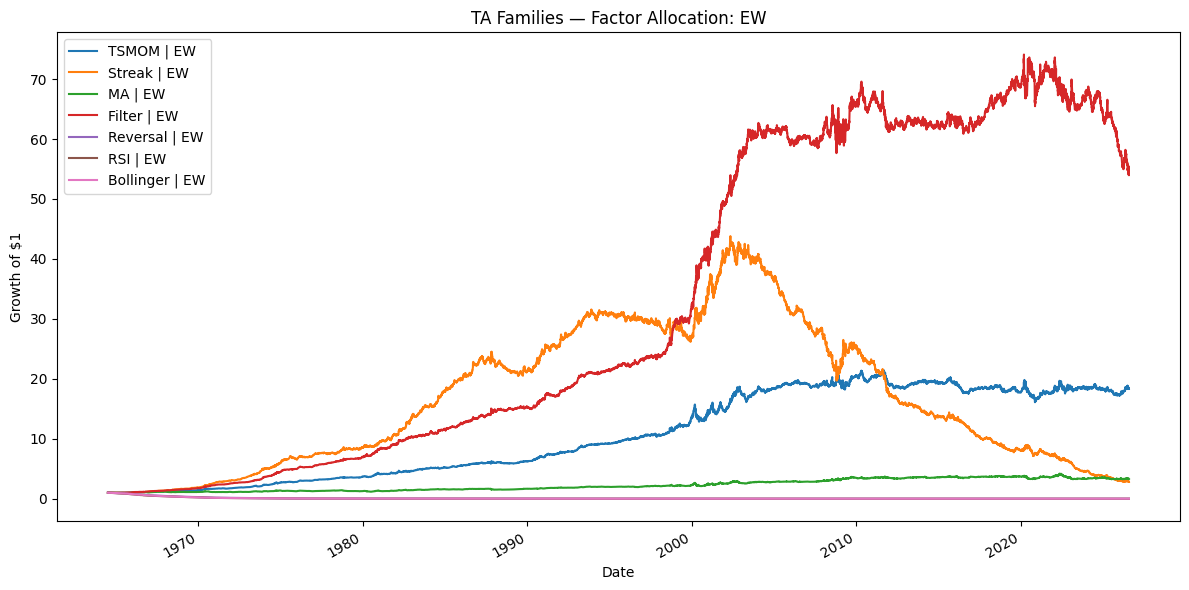

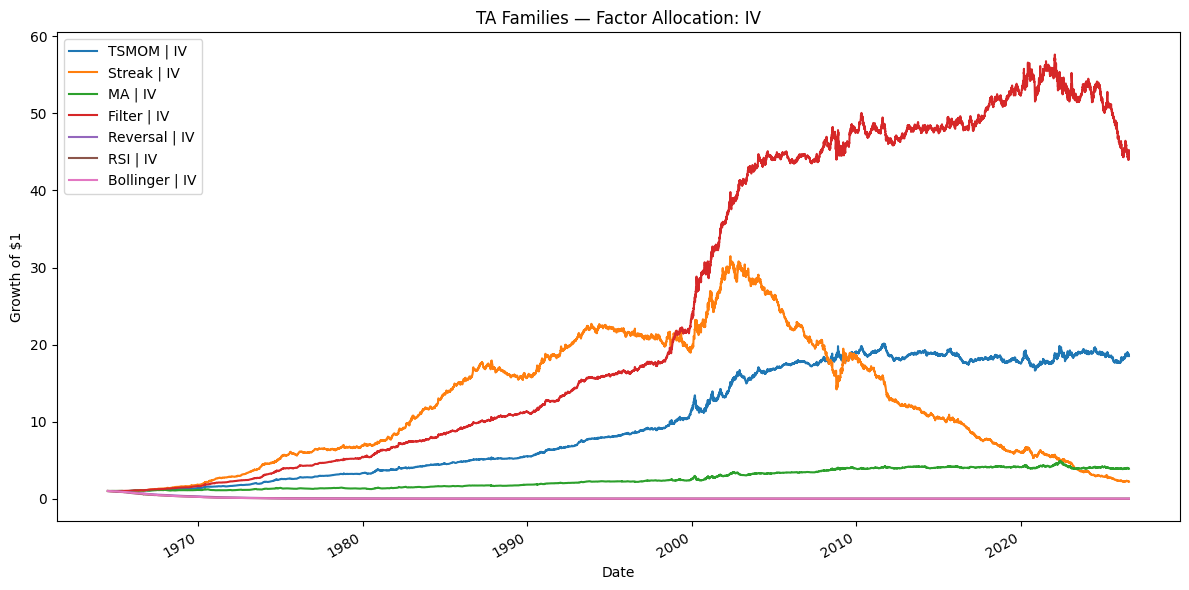

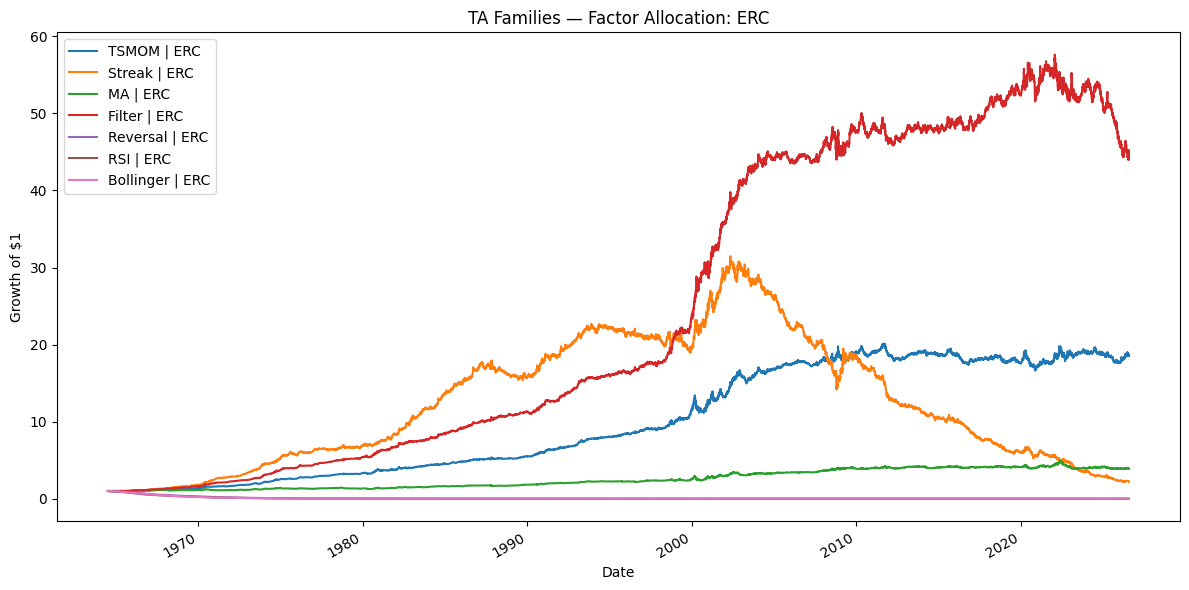

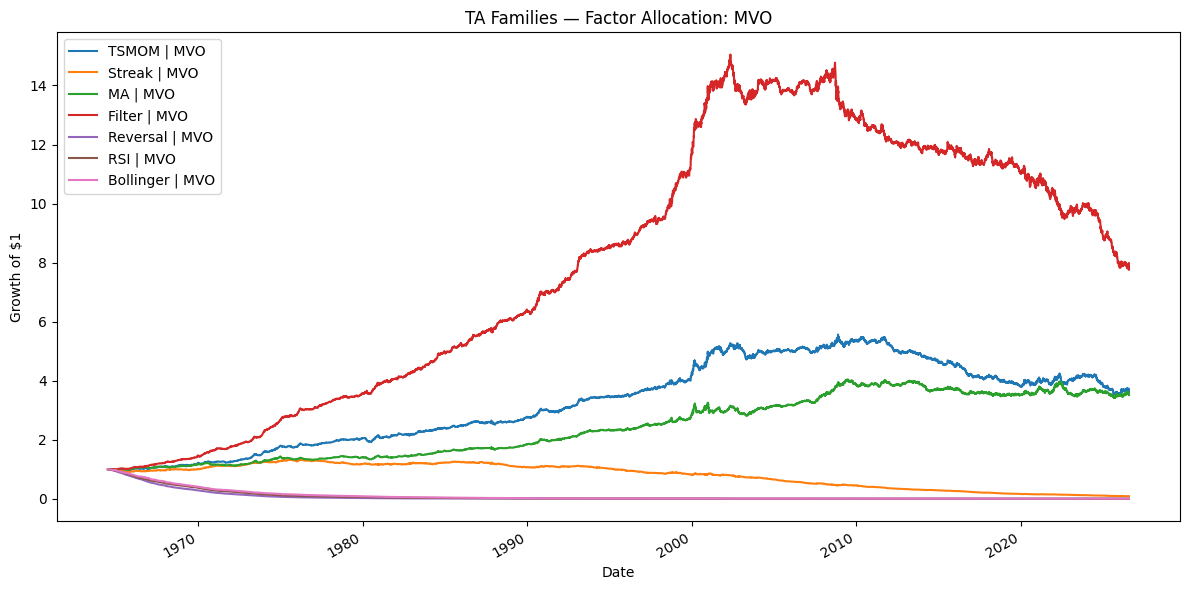

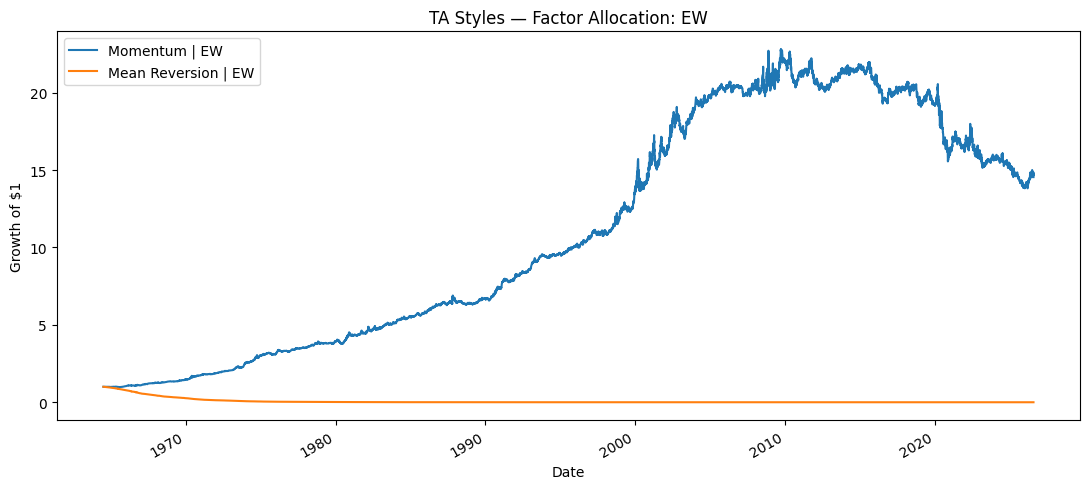

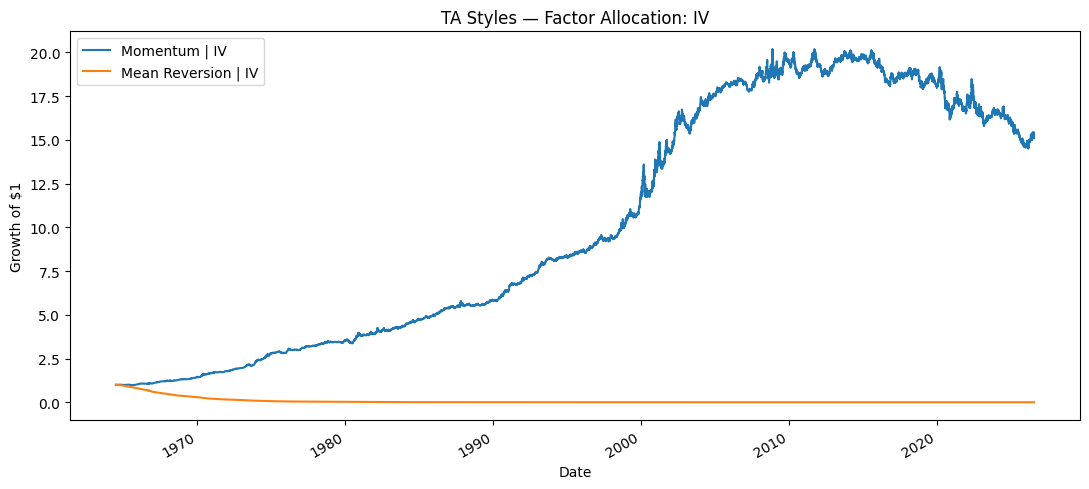

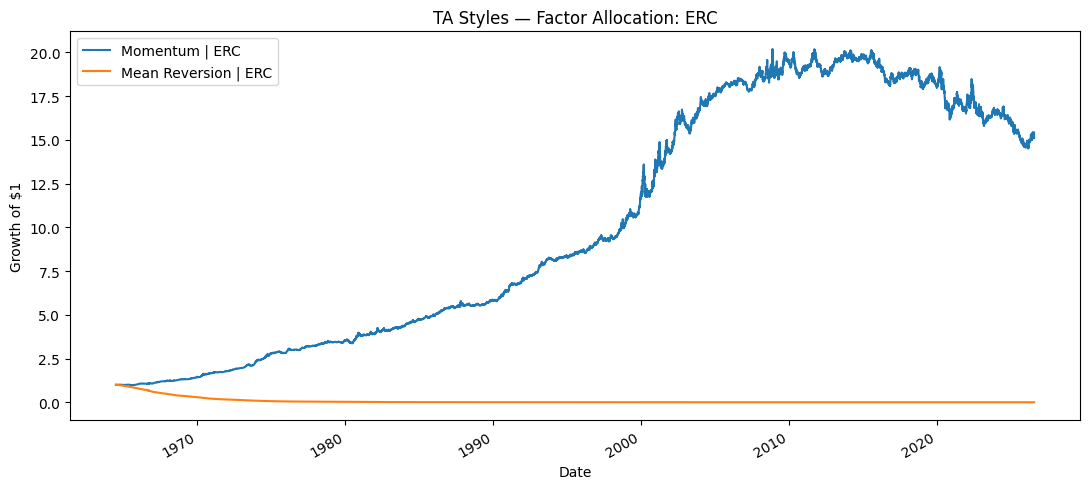

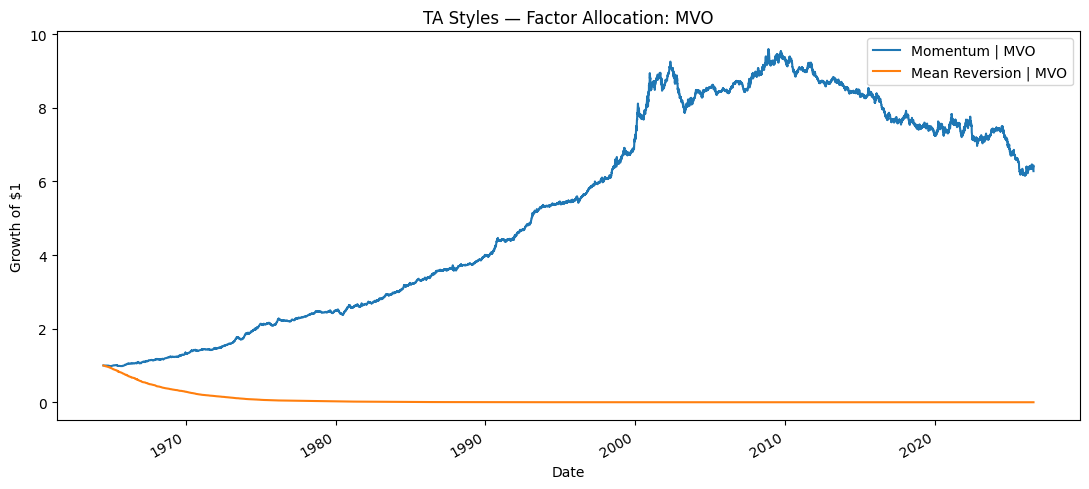

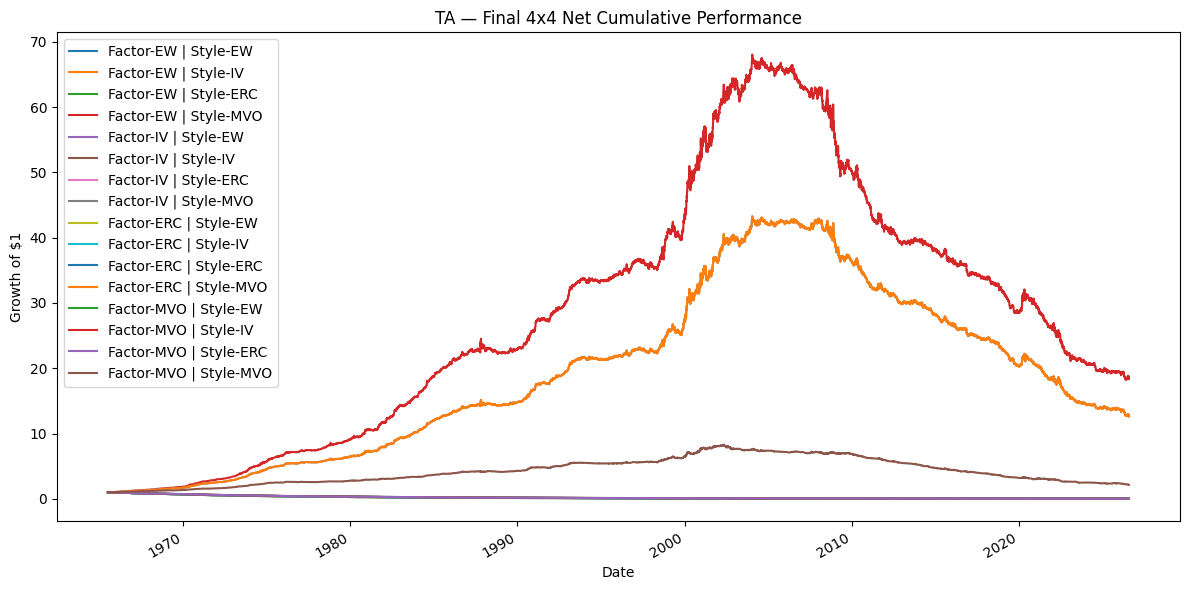

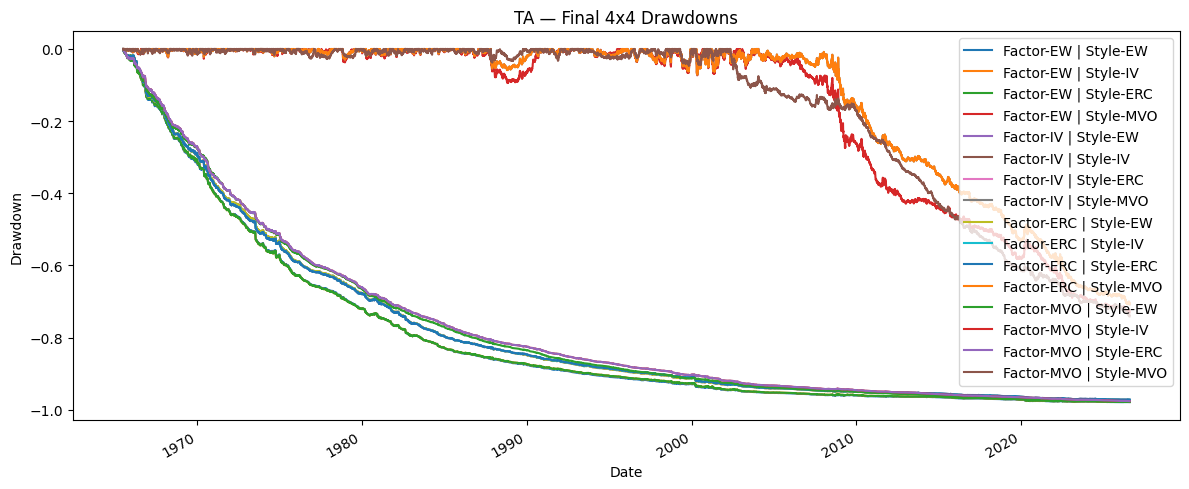

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.stats import skew
from sklearn.covariance import LedoitWolf
from IPython.display import display


# ============================================================
# SETTINGS
# ============================================================

LOOKBACK = 252
COST_BPS = 10
RULES = ["EW", "IV", "ERC", "MVO"]

N_BOOT = 5000
BOOT_BLOCK = 20
BOOT_CHUNK = 500
SEED = 42


# ============================================================
# DATA
# ============================================================

def prepare_ff(ff6, factor_cols):
    # Fama-French library convention: 1.00 = 1%.
    r = ff6[factor_cols].copy().sort_index().astype(float) / 100.0
    r = r[~r.index.duplicated(keep="last")].dropna(how="any")
    px = (1 + r).cumprod()
    return r, px


# ============================================================
# DISCRETE PARAMETER-LEVEL SIGNALS: {-1, 0, +1}
# ============================================================

def tsmom(px, n):
    return np.sign(px / px.shift(n) - 1)


def streak(r, n):
    up = r.gt(0).rolling(n).sum().eq(n)
    down = r.lt(0).rolling(n).sum().eq(n)
    return pd.DataFrame(np.select([up, down], [1.0, -1.0], default=0.0), index=r.index, columns=r.columns)


def ma_cross(px, fast, slow):
    return np.sign(px.rolling(fast).mean() - px.rolling(slow).mean())


def filter_signal(px, threshold):
    p = px.to_numpy(float)
    out = np.zeros_like(p)

    for j in range(p.shape[1]):
        state, peak, trough = 0, p[0, j], p[0, j]

        for i in range(1, p.shape[0]):
            x = p[i, j]

            if state == 0:
                peak, trough = max(peak, x), min(trough, x)
                if x >= trough * (1 + threshold):
                    state, peak = 1, x
                elif x <= peak * (1 - threshold):
                    state, trough = -1, x
            elif state == 1:
                peak = max(peak, x)
                if x <= peak * (1 - threshold):
                    state, trough = -1, x
            else:
                trough = min(trough, x)
                if x >= trough * (1 + threshold):
                    state, peak = 1, x

            out[i, j] = state

    return pd.DataFrame(out, index=px.index, columns=px.columns)


def reversal(px, n):
    return -np.sign(px / px.shift(n) - 1)


def rsi_signal(px, n):
    d = px.diff()
    gain = d.clip(lower=0).ewm(alpha=1 / n, adjust=False, min_periods=n).mean()
    loss = (-d.clip(upper=0)).ewm(alpha=1 / n, adjust=False, min_periods=n).mean()
    rs = gain / loss.replace(0, np.nan)
    rsi = 100 - 100 / (1 + rs)
    return pd.DataFrame(np.select([rsi < 30, rsi > 70], [1.0, -1.0], default=0.0), index=px.index, columns=px.columns)


def bollinger_reversion(px, n):
    ma = px.rolling(n).mean()
    sd = px.rolling(n).std(ddof=1)
    return pd.DataFrame(
        np.select([px < ma - 2 * sd, px > ma + 2 * sd], [1.0, -1.0], default=0.0),
        index=px.index,
        columns=px.columns
    )


# ============================================================
# PARAMETER -> FAMILY -> STYLE
# ============================================================

def average_parameterisations(frames):
    return sum(frames) / len(frames)


def build_ta_signals(r, px):
    momentum_families = {
        "TSMOM": average_parameterisations([tsmom(px, 21), tsmom(px, 63), tsmom(px, 252)]),
        "Streak": average_parameterisations([streak(r, 3), streak(r, 5), streak(r, 7)]),
        "MA": average_parameterisations([ma_cross(px, 20, 50), ma_cross(px, 50, 100), ma_cross(px, 50, 200)]),
        "Filter": average_parameterisations([filter_signal(px, 0.01), filter_signal(px, 0.02), filter_signal(px, 0.05)])
    }

    meanrev_families = {
        "Reversal": average_parameterisations([reversal(px, 1), reversal(px, 3), reversal(px, 5)]),
        "RSI": average_parameterisations([rsi_signal(px, 7), rsi_signal(px, 14), rsi_signal(px, 28)]),
        "Bollinger": average_parameterisations([
            bollinger_reversion(px, 20),
            bollinger_reversion(px, 50),
            bollinger_reversion(px, 100)
        ])
    }

    # Each parameter signal is discrete. Family/style scores are equal-weight
    # consensus votes and therefore lie continuously in [-1, 1].
    momentum = sum(momentum_families.values()) / len(momentum_families)
    mean_reversion = sum(meanrev_families.values()) / len(meanrev_families)
    families = {**momentum_families, **meanrev_families}
    return momentum, mean_reversion, families, momentum_families, meanrev_families


# ============================================================
# ALLOCATION
# ============================================================

def norm_gross(w):
    w = np.asarray(w, float)
    gross = np.abs(w).sum()
    return w / gross if np.isfinite(gross) and gross > 1e-12 else np.zeros_like(w)


def erc_long_weights(Sigma):
    Sigma = np.asarray(Sigma, float)
    n = len(Sigma)
    vol = np.sqrt(np.maximum(np.diag(Sigma), 1e-12))
    x0 = (1 / vol) / (1 / vol).sum()

    def objective(w):
        rc = w * (Sigma @ w)
        return ((rc - rc.mean()) ** 2).sum()

    result = minimize(
        objective,
        x0,
        method="SLSQP",
        bounds=[(1e-8, 1.0)] * n,
        constraints={"type": "eq", "fun": lambda w: w.sum() - 1},
        options={"maxiter": 300, "ftol": 1e-10, "disp": False}
    )

    if not result.success:
        raise RuntimeError(f"ERC failed: {result.message}")

    return result.x / result.x.sum()


def signed_erc_from_stats(Sigma, direction, cache):
    direction = np.asarray(direction, float)
    active = np.isfinite(direction) & (direction != 0)
    out = np.zeros(len(direction))

    if not active.any():
        return out

    key = tuple(direction.astype(np.int8))
    if key in cache:
        return cache[key].copy()

    signs = direction[active]
    Sigma_active = Sigma[np.ix_(active, active)]
    D = np.diag(signs)
    magnitudes = erc_long_weights(D @ Sigma_active @ D)
    out[active] = signs * magnitudes
    out = norm_gross(out)
    cache[key] = out.copy()
    return out


def allocate_from_stats(rule, signal, Sigma, invSigma, vol, erc_cache):
    signal = np.asarray(signal, float)
    signal = np.where(np.isfinite(signal), signal, 0.0)
    direction = np.sign(signal)

    if not np.any(direction != 0):
        return np.zeros_like(signal)

    if rule == "EW":
        return norm_gross(direction)
    if rule == "IV":
        return norm_gross(direction / vol)
    if rule == "ERC":
        return signed_erc_from_stats(Sigma, direction, erc_cache)
    if rule == "MVO":
        # Continuous family/style consensus is used as the expected-return score.
        return norm_gross(invSigma @ signal)

    raise ValueError(rule)


# ============================================================
# FACTOR-LEVEL WEIGHTS
# One rolling covariance fit per date, reused by every family/style.
# ERC is additionally cached by the date's unique sign pattern.
# ============================================================

def build_all_factor_weights(r, signal_map):
    out = {name: {rule: [] for rule in RULES} for name in signal_map}
    r_values = r.to_numpy(float)

    for pos in range(LOOKBACK, len(r)):
        t = r.index[pos]
        hist = r_values[pos - LOOKBACK + 1:pos + 1]

        if len(hist) < int(0.9 * LOOKBACK):
            continue

        Sigma = LedoitWolf().fit(hist).covariance_
        invSigma = np.linalg.pinv(Sigma)
        vol = np.sqrt(np.maximum(np.diag(Sigma), 1e-12))
        erc_cache = {}

        for name, signal in signal_map.items():
            s = signal.iloc[pos].fillna(0.0).to_numpy(float)

            for rule in RULES:
                w = allocate_from_stats(rule, s, Sigma, invSigma, vol, erc_cache)
                out[name][rule].append(pd.Series(w, index=r.columns, name=t))

    return {
        name: {rule: pd.DataFrame(rows) for rule, rows in by_rule.items()}
        for name, by_rule in out.items()
    }


# ============================================================
# RETURNS / TURNOVER
# Weight formed at t earns factor return at t+1.
# ============================================================

def gross_returns_from_weights(weights, r):
    idx = weights.index.intersection(r.index)
    return weights.loc[idx].shift(1).mul(r.loc[idx]).sum(axis=1, min_count=1)


def turnover_from_weights(weights):
    turnover = 0.5 * weights.diff().abs().sum(axis=1, min_count=1)
    if len(turnover):
        turnover.iloc[0] = 0.0
    return turnover


def net_returns_from_weights(weights, r):
    gross = gross_returns_from_weights(weights, r)
    turnover = turnover_from_weights(weights)
    # Return at t uses w_(t-1), so entry cost for w_(t-1) is charged at t.
    cost = COST_BPS / 10_000 * turnover.shift(1)
    return gross - cost, turnover, gross


# ============================================================
# STYLE ALLOCATION: MOMENTUM VS MEAN REVERSION
# ============================================================

def build_all_style_weights(style_returns):
    rows = {rule: [] for rule in RULES}
    values = style_returns.to_numpy(float)

    for pos in range(LOOKBACK, len(style_returns)):
        t = style_returns.index[pos]
        hist = values[pos - LOOKBACK + 1:pos + 1]

        if len(hist) < int(0.9 * LOOKBACK):
            continue

        Sigma = LedoitWolf().fit(hist).covariance_
        vol = np.sqrt(np.maximum(np.diag(Sigma), 1e-12))

        rows["EW"].append(pd.Series(np.ones(2) / 2, index=style_returns.columns, name=t))
        rows["IV"].append(pd.Series(norm_gross(1 / vol), index=style_returns.columns, name=t))

        # With exactly two long sleeves, equal-risk-contribution weights are
        # algebraically identical to inverse-volatility weights.
        rows["ERC"].append(pd.Series(norm_gross(1 / vol), index=style_returns.columns, name=t))

        mu = hist.mean(axis=0)
        rows["MVO"].append(pd.Series(norm_gross(np.linalg.pinv(Sigma) @ mu), index=style_returns.columns, name=t))

    return {rule: pd.DataFrame(x) for rule, x in rows.items()}


# ============================================================
# FULL BACKTEST
# ============================================================

def run_ta_4x4(ff6, factor_cols):
    r, px = prepare_ff(ff6, factor_cols)
    momentum, mean_reversion, families, momentum_families, meanrev_families = build_ta_signals(r, px)

    signal_map = {**families, "Momentum": momentum, "Mean Reversion": mean_reversion}
    all_factor_weights = build_all_factor_weights(r, signal_map)

    # --------------------------------------------------------
    # FAMILY BREAKDOWN: seven actual families
    # --------------------------------------------------------

    family_returns, family_turnovers, family_weights = {}, {}, {}

    for family_name in families:
        for rule in RULES:
            w = all_factor_weights[family_name][rule]
            net, turnover, _ = net_returns_from_weights(w, r)
            name = f"{family_name} | {rule}"
            family_returns[name] = net
            family_turnovers[name] = turnover
            family_weights[name] = w

    family_returns = pd.DataFrame(family_returns).dropna(how="any")
    family_turnovers = pd.DataFrame(family_turnovers).reindex(family_returns.index)

    # --------------------------------------------------------
    # STYLE BREAKDOWN
    # --------------------------------------------------------

    momentum_weights = all_factor_weights["Momentum"]
    meanrev_weights = all_factor_weights["Mean Reversion"]
    style_returns, style_turnovers, style_weights = {}, {}, {}

    for rule in RULES:
        mom_net, mom_turn, _ = net_returns_from_weights(momentum_weights[rule], r)
        mr_net, mr_turn, _ = net_returns_from_weights(meanrev_weights[rule], r)
        style_returns[f"Momentum | {rule}"] = mom_net
        style_returns[f"Mean Reversion | {rule}"] = mr_net
        style_turnovers[f"Momentum | {rule}"] = mom_turn
        style_turnovers[f"Mean Reversion | {rule}"] = mr_turn
        style_weights[f"Momentum | {rule}"] = momentum_weights[rule]
        style_weights[f"Mean Reversion | {rule}"] = meanrev_weights[rule]

    style_returns = pd.DataFrame(style_returns).dropna(how="any")
    style_turnovers = pd.DataFrame(style_turnovers).reindex(style_returns.index)

    # --------------------------------------------------------
    # FINAL 4x4
    # factor allocation within each style x style allocation
    # --------------------------------------------------------

    final_returns, final_turnovers, final_weights = {}, {}, {}

    for factor_rule in RULES:
        mom_w = momentum_weights[factor_rule]
        mr_w = meanrev_weights[factor_rule]

        # Use gross sleeve returns for the upper allocation layer so costs are
        # charged only once, on the final combined factor portfolio.
        style_gross = pd.DataFrame({
            "Momentum": gross_returns_from_weights(mom_w, r),
            "Mean Reversion": gross_returns_from_weights(mr_w, r)
        }).dropna(how="any")

        style_allocations = build_all_style_weights(style_gross)

        for style_rule in RULES:
            sw = style_allocations[style_rule]
            idx = sw.index.intersection(mom_w.index).intersection(mr_w.index)
            sw, mom, mr = sw.loc[idx], mom_w.loc[idx], mr_w.loc[idx]

            # Do not re-normalize after combining sleeves: offsetting Momentum/MR
            # positions are genuine netting/diversification, so final gross can be < 1.
            final_w = mom.mul(sw["Momentum"], axis=0) + mr.mul(sw["Mean Reversion"], axis=0)
            net, turnover, _ = net_returns_from_weights(final_w, r)

            name = f"Factor-{factor_rule} | Style-{style_rule}"
            final_returns[name] = net
            final_turnovers[name] = turnover
            final_weights[name] = final_w

    returns = pd.DataFrame(final_returns).dropna(how="any")
    turnovers = pd.DataFrame(final_turnovers).reindex(returns.index)

    return (
        returns, turnovers, final_weights,
        family_returns, family_turnovers, family_weights,
        style_returns, style_turnovers, style_weights,
        families, momentum_families, meanrev_families, r, px
    )


# ============================================================
# PERFORMANCE
# ============================================================

def stationary_bootstrap_sharpe_ci(r, n_boot=N_BOOT, mean_block=BOOT_BLOCK, seed=SEED, chunk=BOOT_CHUNK):
    x = pd.Series(r).dropna().to_numpy(float)
    n = len(x)

    if n < 2:
        return np.nan, np.nan

    rng = np.random.default_rng(seed)
    p = 1 / mean_block
    sharpes = []

    for start in range(0, n_boot, chunk):
        b = min(chunk, n_boot - start)
        idx = np.empty((b, n), dtype=np.int32)
        idx[:, 0] = rng.integers(0, n, size=b)

        for t in range(1, n):
            restart = rng.random(b) < p
            fresh = rng.integers(0, n, size=b)
            idx[:, t] = np.where(restart, fresh, (idx[:, t - 1] + 1) % n)

        sample = x[idx]
        sd = sample.std(axis=1, ddof=1)
        sr = np.sqrt(252) * sample.mean(axis=1) / sd
        sharpes.append(sr[np.isfinite(sr)])

    sharpes = np.concatenate(sharpes) if sharpes else np.array([])
    return np.quantile(sharpes, [0.025, 0.975]) if len(sharpes) else (np.nan, np.nan)


def max_dd(r):
    wealth = (1 + r).cumprod()
    return (wealth / wealth.cummax() - 1).min()


def performance_table(returns, turnovers, bootstrap_ci=True):
    rows = []

    for j, name in enumerate(returns.columns):
        x = returns[name].dropna()
        n = len(x)
        sd = x.std(ddof=1)
        terminal = (1 + x).prod()
        row = {
            "Strategy": name,
            "Arithmetic Return": 252 * x.mean(),
            "Geometric Return": terminal ** (252 / n) - 1 if terminal > 0 else np.nan,
            "Volatility": np.sqrt(252) * sd,
            "Sharpe": np.sqrt(252) * x.mean() / sd if sd > 0 else np.nan,
            "Skew": skew(x, bias=False),
            "Max Drawdown": max_dd(x),
            "Turnover": turnovers.loc[x.index, name].mean()
        }

        if bootstrap_ci:
            lo, hi = stationary_bootstrap_sharpe_ci(x, seed=SEED + j)
            row["Sharpe CI Low"] = lo
            row["Sharpe CI High"] = hi

        rows.append(row)

    result = pd.DataFrame(rows).set_index("Strategy")
    order = [
        "Arithmetic Return", "Geometric Return", "Volatility", "Sharpe",
        "Sharpe CI Low", "Sharpe CI High", "Skew", "Max Drawdown", "Turnover"
    ]
    return result[[c for c in order if c in result.columns]]


# ============================================================
# RUN / OUTPUT
# ============================================================

(
    ta_returns, ta_turnovers, ta_weights,
    family_returns, family_turnovers, family_weights,
    style_returns, style_turnovers, style_weights,
    families, momentum_families, meanrev_families,
    ff_returns, ff_index
) = run_ta_4x4(ff6, FACTOR_COLS)

PERFORMANCE_FORMAT = {
    "Arithmetic Return": "{:.2%}",
    "Geometric Return": "{:.2%}",
    "Volatility": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Sharpe CI Low": "{:.2f}",
    "Sharpe CI High": "{:.2f}",
    "Skew": "{:.2f}",
    "Max Drawdown": "{:.2%}",
    "Turnover": "{:.2%}"
}

# Family/style tables are diagnostics: avoid 36 redundant 5,000-replicate
# daily bootstraps. The headline final 4x4 retains the full bootstrap CIs.
family_results = performance_table(family_returns, family_turnovers, bootstrap_ci=False)
style_results = performance_table(style_returns, style_turnovers, bootstrap_ci=False)
ta_results = performance_table(ta_returns, ta_turnovers, bootstrap_ci=True)

print("\nFAMILY PERFORMANCE")
display(family_results.style.format(PERFORMANCE_FORMAT, na_rep="—"))

family_names = ["TSMOM", "Streak", "MA", "Filter", "Reversal", "RSI", "Bollinger"]
family_sharpe_grid = pd.DataFrame(index=RULES, columns=family_names, dtype=float)
for rule in RULES:
    for family in family_names:
        family_sharpe_grid.loc[rule, family] = family_results.loc[f"{family} | {rule}", "Sharpe"]
family_sharpe_grid.index.name = "Factor allocation"
print("\nFAMILY SHARPE BREAKDOWN")
display(family_sharpe_grid.style.format("{:.2f}"))

print("\nSTYLE PERFORMANCE")
display(style_results.style.format(PERFORMANCE_FORMAT, na_rep="—"))

style_sharpe_grid = pd.DataFrame(index=RULES, columns=["Momentum", "Mean Reversion"], dtype=float)
for rule in RULES:
    style_sharpe_grid.loc[rule, "Momentum"] = style_results.loc[f"Momentum | {rule}", "Sharpe"]
    style_sharpe_grid.loc[rule, "Mean Reversion"] = style_results.loc[f"Mean Reversion | {rule}", "Sharpe"]
style_sharpe_grid.index.name = "Factor allocation"
print("\nSTYLE SHARPE BREAKDOWN")
display(style_sharpe_grid.style.format("{:.2f}"))

print("\nFINAL 4x4 PERFORMANCE")
display(ta_results.style.format(PERFORMANCE_FORMAT, na_rep="—"))

final_sharpe_grid = pd.DataFrame(index=RULES, columns=RULES, dtype=float)
for factor_rule in RULES:
    for style_rule in RULES:
        final_sharpe_grid.loc[factor_rule, style_rule] = ta_results.loc[f"Factor-{factor_rule} | Style-{style_rule}", "Sharpe"]
final_sharpe_grid.index.name = "Factor allocation"
final_sharpe_grid.columns.name = "Style allocation"
print("\nFINAL 4x4 SHARPE GRID")
display(final_sharpe_grid.style.format("{:.2f}"))

print("\nFF DAILY RETURNS AFTER /100")
display(ff_returns.describe().T[["mean", "std", "min", "max"]].style.format("{:.4f}"))
print(f"Final common OOS: {ta_returns.index.min().date()} to {ta_returns.index.max().date()} | {len(ta_returns)} daily observations")

family_wealth = (1 + family_returns).cumprod()
for rule in RULES:
    cols = [f"{family} | {rule}" for family in family_names]
    family_wealth[cols].plot(figsize=(12, 6), title=f"TA Families — Factor Allocation: {rule}")
    plt.ylabel("Growth of $1")
    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()

style_wealth = (1 + style_returns).cumprod()
for rule in RULES:
    style_wealth[[f"Momentum | {rule}", f"Mean Reversion | {rule}"]].plot(
        figsize=(11, 5), title=f"TA Styles — Factor Allocation: {rule}"
    )
    plt.ylabel("Growth of $1")
    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()

wealth = (1 + ta_returns).cumprod()
wealth.plot(figsize=(12, 6), title="TA — Final 4x4 Net Cumulative Performance")
plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

(wealth / wealth.cummax() - 1).plot(figsize=(12, 5), title="TA — Final 4x4 Drawdowns")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.tight_layout()
plt.show()


##Monthly


MONTHLY TA — FAMILY PERFORMANCE


,Arithmetic Return,Geometric Return,Volatility,Sharpe,Skew,Max Drawdown,Turnover
Strategy,,,,,,,
TSMOM | EW,3.18%,3.02%,6.44%,0.49,0.05,-25.60%,28.41%
TSMOM | IV,3.05%,2.93%,5.72%,0.53,0.21,-25.19%,29.24%
TSMOM | ERC,3.05%,2.93%,5.72%,0.53,0.21,-25.19%,29.24%
TSMOM | MVO,3.07%,3.02%,4.32%,0.71,-0.62,-12.08%,45.19%
Streak | EW,0.72%,0.36%,8.45%,0.09,-0.61,-62.70%,71.84%
Streak | IV,0.80%,0.47%,8.11%,0.10,-0.65,-60.26%,72.17%
Streak | ERC,0.80%,0.47%,8.11%,0.10,-0.65,-60.26%,72.17%
Streak | MVO,0.53%,0.47%,3.48%,0.15,-0.01,-23.63%,62.21%
MA | EW,2.16%,1.98%,6.30%,0.34,-0.25,-22.49%,17.47%



MONTHLY TA — FAMILY SHARPE BREAKDOWN


,TSMOM,Streak,MA,Filter,Reversal,RSI,Bollinger
Factor allocation,,,,,,,
EW,0.49,0.09,0.34,0.46,-0.34,-0.63,-0.60
IV,0.53,0.10,0.39,0.60,-0.42,-0.69,-0.61
ERC,0.53,0.10,0.39,0.60,-0.42,-0.69,-0.61
MVO,0.71,0.15,0.52,0.83,-0.63,-0.85,-0.86



MONTHLY TA — STYLE PERFORMANCE


...


FF DAILY RETURNS AFTER /100


,mean,std,min,max
Mkt-RF,0.0003,0.0102,-0.1744,0.1136
SMB,0.0001,0.0055,-0.1115,0.0608
HML,0.0001,0.0059,-0.0503,0.0673
RMW,0.0001,0.0041,-0.0296,0.0457
CMA,0.0001,0.0039,-0.0530,0.0247
Mom,0.0003,0.0079,-0.1439,0.0712



FF MONTHLY RETURNS


,mean,std,min,max
Mkt-RF,0.0060,0.0445,-0.2309,0.1603
SMB,0.0015,0.0302,-0.1456,0.1835
HML,0.0032,0.0297,-0.1464,0.1376
RMW,0.0027,0.0228,-0.1576,0.1532
CMA,0.0026,0.0208,-0.0691,0.1020
Mom,0.0063,0.0418,-0.2677,0.1894


Monthly common OOS: 1965-07-31 to 2026-07-31 | 733 months


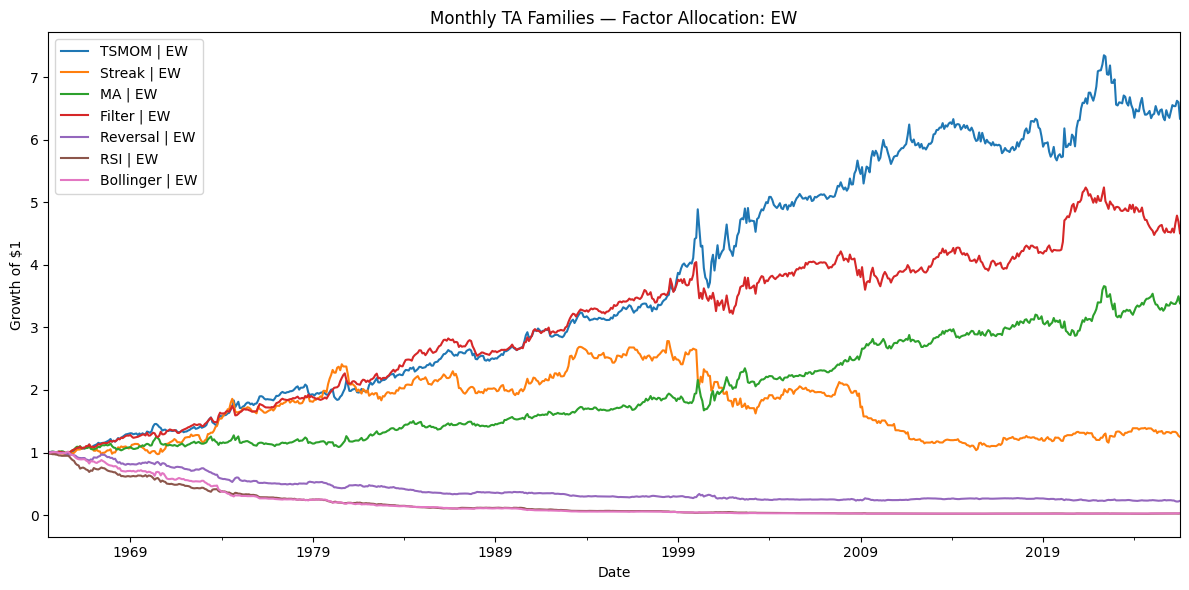

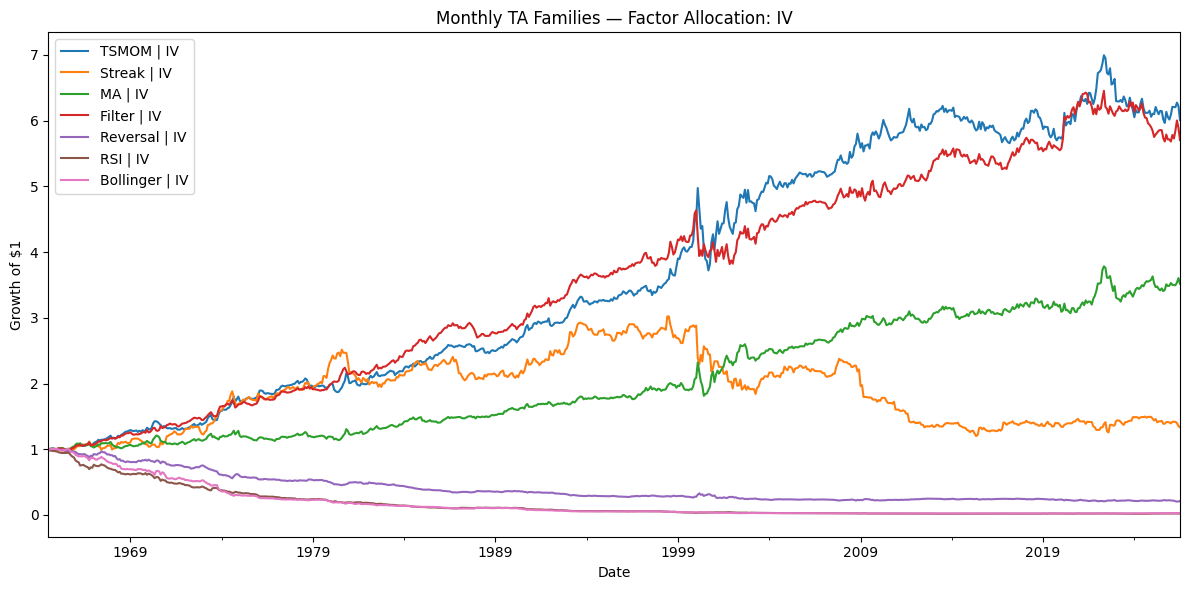

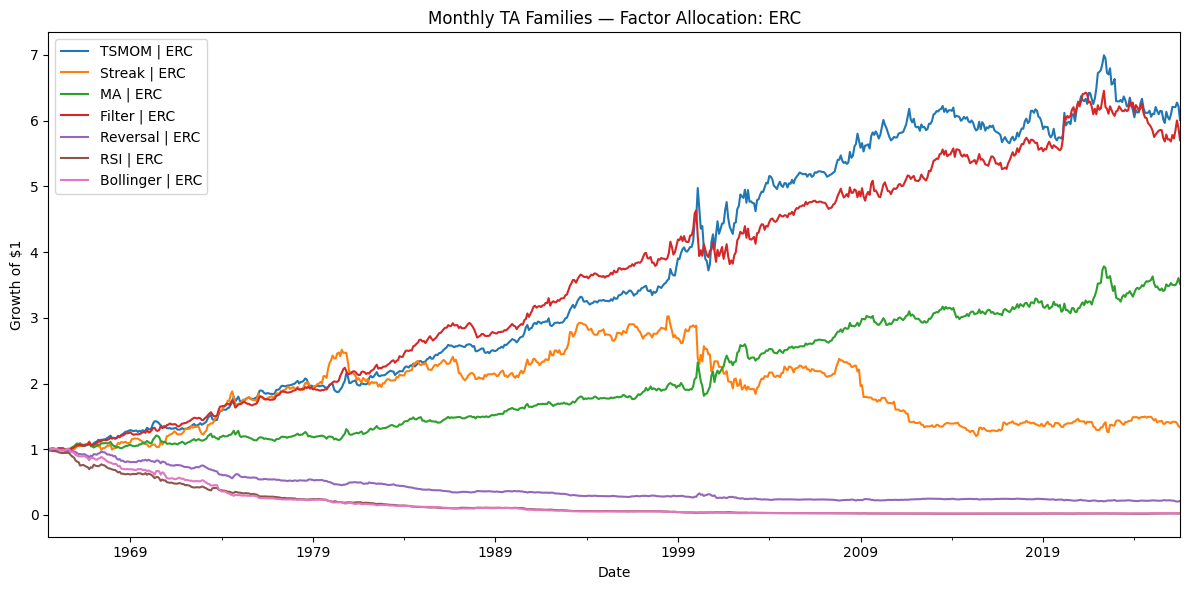

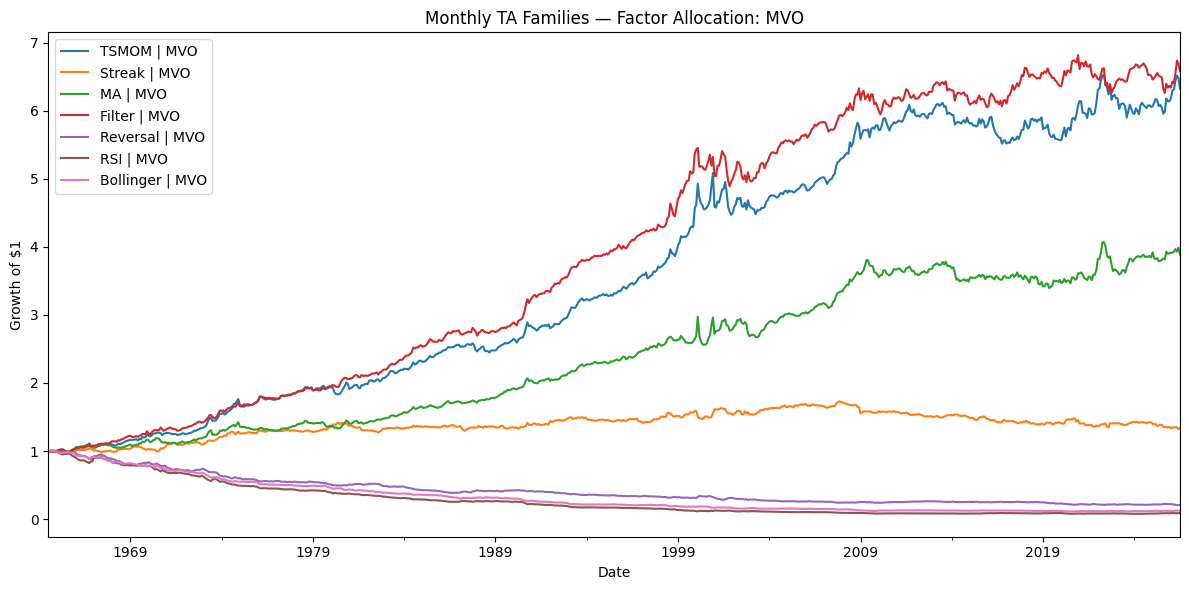

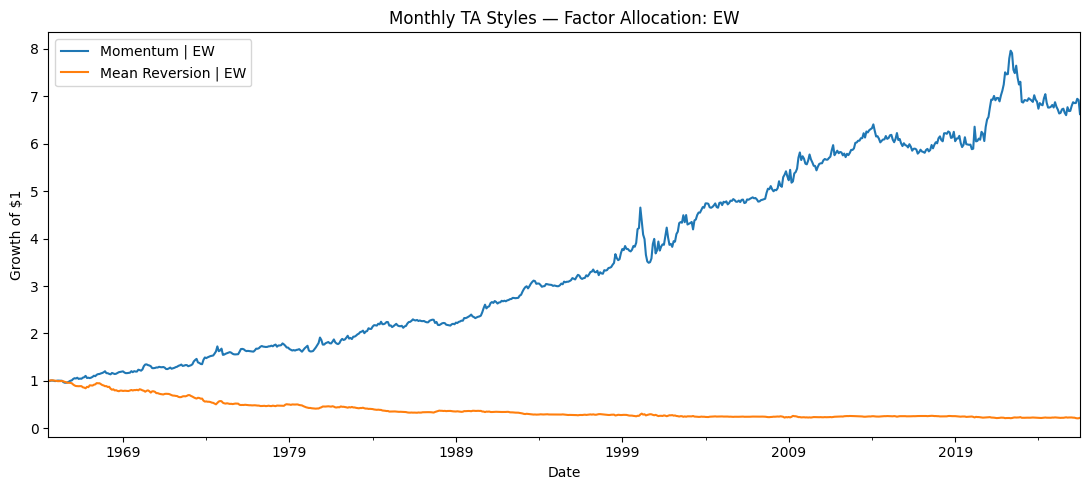

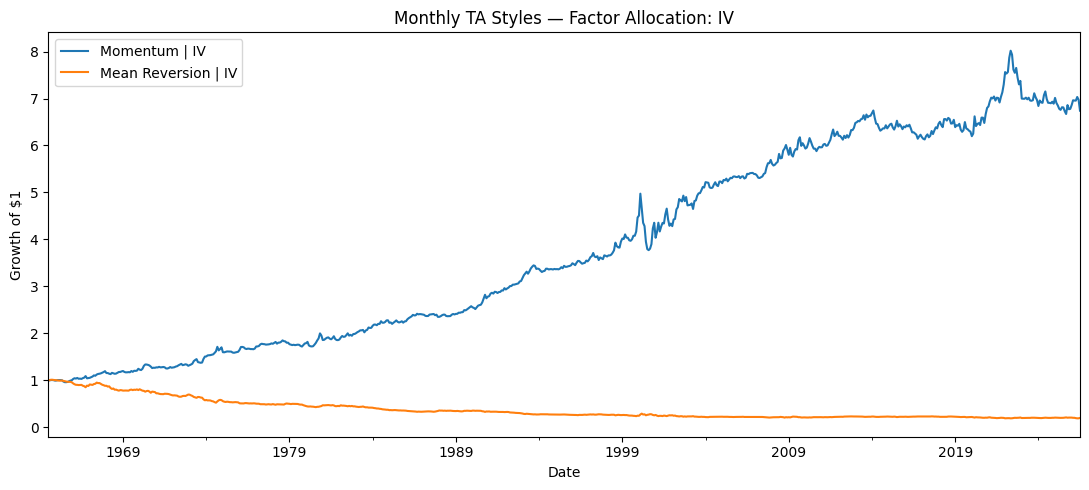

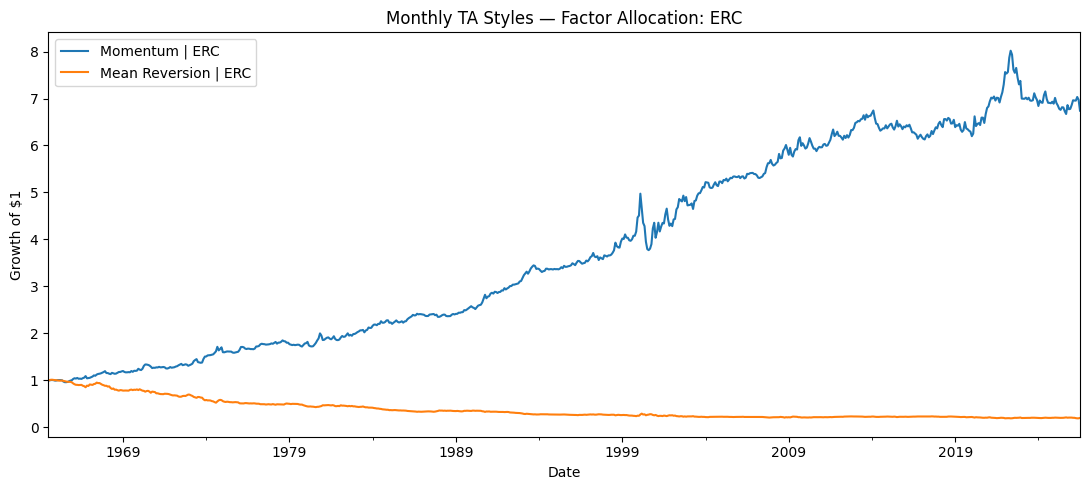

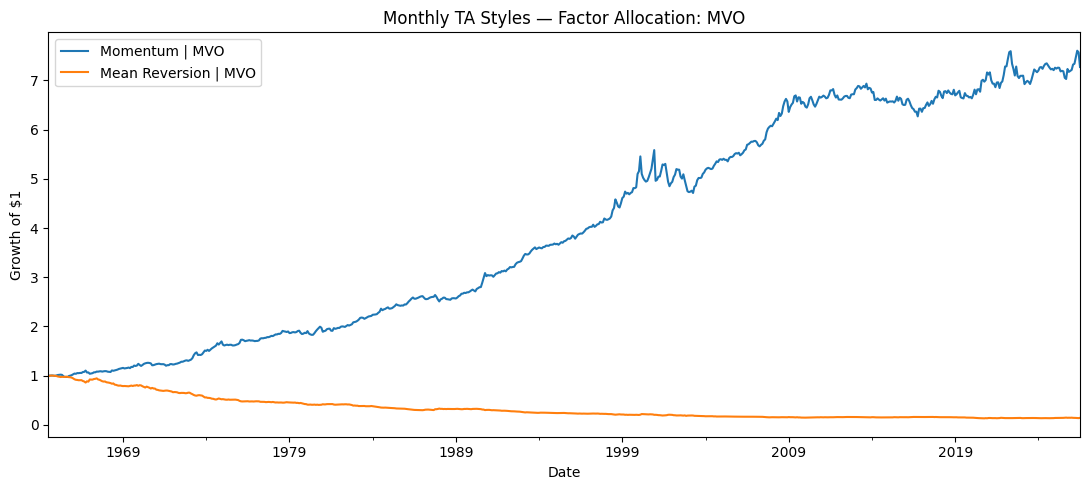

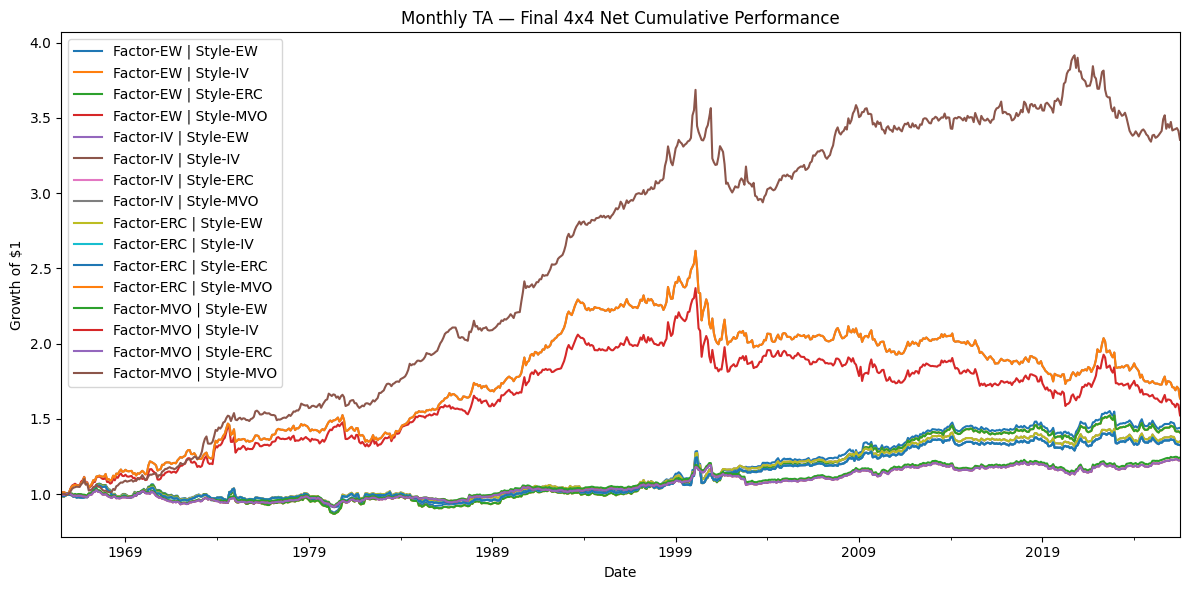

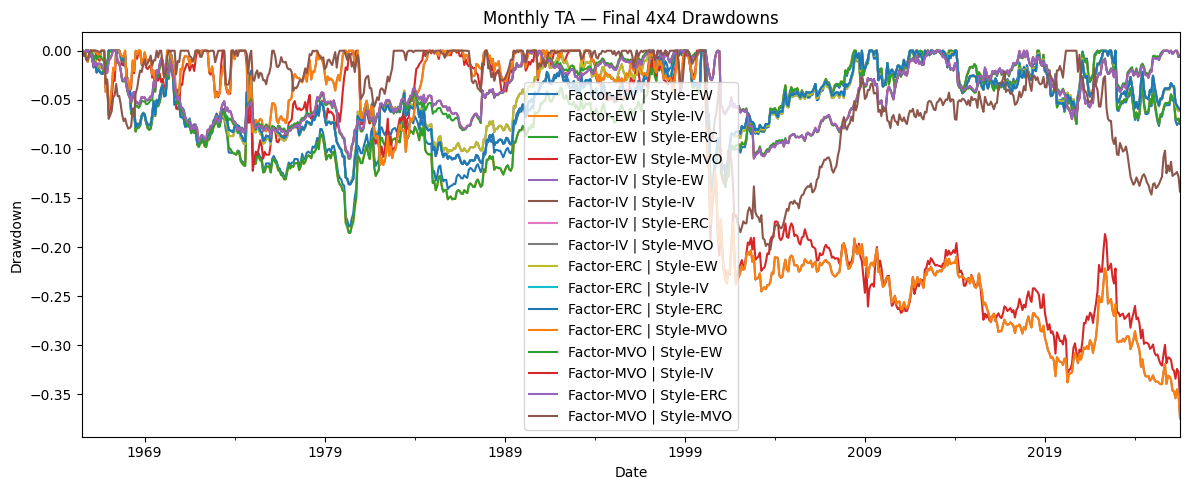

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.stats import skew
from sklearn.covariance import LedoitWolf
from IPython.display import display


# ============================================================
# SETTINGS
# ============================================================

FACTOR_LOOKBACK_DAYS = 252
STYLE_LOOKBACK_MONTHS = 12
COST_BPS = 10
RULES = ["EW", "IV", "ERC", "MVO"]

N_BOOT = 5000
BOOT_BLOCK = 6
BOOT_CHUNK = 500
SEED = 42


# ============================================================
# DATA
# ============================================================

def prepare_ff(ff6, factor_cols):
    # Fama-French library convention: 1.00 = 1%.
    r = ff6[factor_cols].copy().sort_index().astype(float) / 100.0
    r = r[~r.index.duplicated(keep="last")]
    r = r.dropna(how="any")
    px = (1 + r).cumprod()
    return r, px


def monthly_factor_returns(r):
    rows = {}

    for period, block in r.groupby(r.index.to_period("M")):
        valid = block.dropna(how="any")

        if len(block) == 0:
            continue
        if len(valid) / len(block) < 0.95:
            continue
        if len(valid) < 15:
            continue

        rows[period] = (1 + valid).prod() - 1

    monthly = pd.DataFrame.from_dict(rows, orient="index")
    monthly.index = pd.PeriodIndex(monthly.index, freq="M")
    return monthly.sort_index()


# ============================================================
# DISCRETE PARAMETER-LEVEL SIGNALS: {-1, 0, +1}
# ============================================================

def tsmom(px, n):
    return np.sign(px / px.shift(n) - 1)


def streak(r, n):
    up = r.gt(0).rolling(n).sum().eq(n)
    down = r.lt(0).rolling(n).sum().eq(n)
    return pd.DataFrame(np.select([up, down], [1.0, -1.0], default=0.0), index=r.index, columns=r.columns)


def ma_cross(px, fast, slow):
    return np.sign(px.rolling(fast).mean() - px.rolling(slow).mean())


def filter_signal(px, threshold):
    p = px.to_numpy(float)
    out = np.zeros_like(p)

    for j in range(p.shape[1]):
        state, peak, trough = 0, p[0, j], p[0, j]

        for i in range(1, p.shape[0]):
            x = p[i, j]

            if state == 0:
                peak, trough = max(peak, x), min(trough, x)
                if x >= trough * (1 + threshold):
                    state, peak = 1, x
                elif x <= peak * (1 - threshold):
                    state, trough = -1, x
            elif state == 1:
                peak = max(peak, x)
                if x <= peak * (1 - threshold):
                    state, trough = -1, x
            else:
                trough = min(trough, x)
                if x >= trough * (1 + threshold):
                    state, peak = 1, x

            out[i, j] = state

    return pd.DataFrame(out, index=px.index, columns=px.columns)


def reversal(px, n):
    return -np.sign(px / px.shift(n) - 1)


def rsi_signal(px, n):
    d = px.diff()
    gain = d.clip(lower=0).ewm(alpha=1 / n, adjust=False, min_periods=n).mean()
    loss = (-d.clip(upper=0)).ewm(alpha=1 / n, adjust=False, min_periods=n).mean()
    rs = gain / loss.replace(0, np.nan)
    rsi = 100 - 100 / (1 + rs)
    return pd.DataFrame(np.select([rsi < 30, rsi > 70], [1.0, -1.0], default=0.0), index=px.index, columns=px.columns)


def bollinger_reversion(px, n):
    ma = px.rolling(n).mean()
    sd = px.rolling(n).std(ddof=1)
    return pd.DataFrame(
        np.select([px < ma - 2 * sd, px > ma + 2 * sd], [1.0, -1.0], default=0.0),
        index=px.index,
        columns=px.columns
    )


# ============================================================
# PARAMETER -> FAMILY -> STYLE
# ============================================================

def average_parameterisations(frames):
    # Direct dataframe addition preserves the original factor-column order.
    return sum(frames) / len(frames)


def build_ta_signals(r, px):
    momentum_families = {
        "TSMOM": average_parameterisations([tsmom(px, 21), tsmom(px, 63), tsmom(px, 252)]),
        "Streak": average_parameterisations([streak(r, 3), streak(r, 5), streak(r, 7)]),
        "MA": average_parameterisations([ma_cross(px, 20, 50), ma_cross(px, 50, 100), ma_cross(px, 50, 200)]),
        "Filter": average_parameterisations([filter_signal(px, 0.01), filter_signal(px, 0.02), filter_signal(px, 0.05)])
    }

    meanrev_families = {
        "Reversal": average_parameterisations([reversal(px, 1), reversal(px, 3), reversal(px, 5)]),
        "RSI": average_parameterisations([rsi_signal(px, 7), rsi_signal(px, 14), rsi_signal(px, 28)]),
        "Bollinger": average_parameterisations([
            bollinger_reversion(px, 20),
            bollinger_reversion(px, 50),
            bollinger_reversion(px, 100)
        ])
    }

    # Parameter signals are discrete. Family/style signals are equal-weight
    # consensus votes and therefore continuous in [-1, 1].
    momentum = sum(momentum_families.values()) / len(momentum_families)
    mean_reversion = sum(meanrev_families.values()) / len(meanrev_families)
    families = {**momentum_families, **meanrev_families}
    return momentum, mean_reversion, families, momentum_families, meanrev_families


# ============================================================
# ALLOCATION
# ============================================================

def norm_gross(w):
    w = np.asarray(w, float)
    gross = np.abs(w).sum()
    return w / gross if np.isfinite(gross) and gross > 1e-12 else np.zeros_like(w)


def erc_long_weights(Sigma):
    Sigma = np.asarray(Sigma, float)
    n = len(Sigma)
    vol = np.sqrt(np.maximum(np.diag(Sigma), 1e-12))
    x0 = (1 / vol) / (1 / vol).sum()

    def objective(w):
        rc = w * (Sigma @ w)
        return ((rc - rc.mean()) ** 2).sum()

    result = minimize(
        objective,
        x0,
        method="SLSQP",
        bounds=[(1e-8, 1.0)] * n,
        constraints={"type": "eq", "fun": lambda w: w.sum() - 1},
        options={"maxiter": 300, "ftol": 1e-10, "disp": False}
    )

    if not result.success:
        raise RuntimeError(f"ERC failed: {result.message}")

    return result.x / result.x.sum()


def signed_erc_from_stats(Sigma, direction, cache):
    direction = np.asarray(direction, float)
    active = np.isfinite(direction) & (direction != 0)
    out = np.zeros(len(direction))

    if not active.any():
        return out

    key = tuple(direction.astype(np.int8))
    if key in cache:
        return cache[key].copy()

    signs = direction[active]
    Sigma_active = Sigma[np.ix_(active, active)]
    D = np.diag(signs)
    magnitudes = erc_long_weights(D @ Sigma_active @ D)
    out[active] = signs * magnitudes
    out = norm_gross(out)
    cache[key] = out.copy()
    return out


def allocate_from_stats(rule, signal, Sigma, invSigma, vol, erc_cache):
    signal = np.asarray(signal, float)
    signal = np.where(np.isfinite(signal), signal, 0.0)
    direction = np.sign(signal)

    if not np.any(direction != 0):
        return np.zeros_like(signal)

    if rule == "EW":
        return norm_gross(direction)
    if rule == "IV":
        return norm_gross(direction / vol)
    if rule == "ERC":
        return signed_erc_from_stats(Sigma, direction, erc_cache)
    if rule == "MVO":
        # Continuous family/style vote is the expected-return score.
        return norm_gross(invSigma @ signal)

    raise ValueError(rule)


# ============================================================
# MONTH-END FACTOR WEIGHTS
# Daily indicators + daily 252-day covariance, sampled monthly.
# One covariance fit per month-end is reused across every family/style.
# ============================================================

def month_end_positions(r):
    positions = {}
    periods = r.index.to_period("M")

    for period in pd.Index(periods).unique():
        pos = np.flatnonzero(periods == period)
        if len(pos):
            positions[period] = pos[-1]

    return positions


def build_all_factor_weights_monthly(r, signal_map):
    out = {name: {rule: [] for rule in RULES} for name in signal_map}
    r_values = r.to_numpy(float)
    month_ends = month_end_positions(r)

    for period, pos in month_ends.items():
        if pos + 1 < FACTOR_LOOKBACK_DAYS:
            continue

        hist = r_values[pos - FACTOR_LOOKBACK_DAYS + 1:pos + 1]
        Sigma = LedoitWolf().fit(hist).covariance_
        invSigma = np.linalg.pinv(Sigma)
        vol = np.sqrt(np.maximum(np.diag(Sigma), 1e-12))
        erc_cache = {}

        for name, signal in signal_map.items():
            s = signal.iloc[pos].fillna(0.0).to_numpy(float)

            for rule in RULES:
                w = allocate_from_stats(rule, s, Sigma, invSigma, vol, erc_cache)
                out[name][rule].append(pd.Series(w, index=r.columns, name=period))

    return {
        name: {rule: pd.DataFrame(rows) for rule, rows in by_rule.items()}
        for name, by_rule in out.items()
    }


# ============================================================
# MONTHLY RETURNS / TURNOVER
# Weight formed at month-end t earns factor return in month t+1.
# Costs are charged once per monthly rebalance.
# ============================================================

def gross_monthly_returns_from_weights(weights, monthly_r):
    if weights.empty:
        return pd.Series(dtype=float)

    w = weights.copy()
    w.index = pd.PeriodIndex(w.index, freq="M") + 1
    idx = w.index.intersection(monthly_r.index)
    return w.loc[idx].mul(monthly_r.loc[idx]).sum(axis=1, min_count=1)


def turnover_from_weights(weights):
    turnover = 0.5 * weights.diff().abs().sum(axis=1, min_count=1)
    if len(turnover):
        turnover.iloc[0] = 0.0
    return turnover


def net_monthly_returns_from_weights(weights, monthly_r):
    gross = gross_monthly_returns_from_weights(weights, monthly_r)
    turnover = turnover_from_weights(weights)

    cost = turnover.copy()
    cost.index = pd.PeriodIndex(cost.index, freq="M") + 1
    cost = COST_BPS / 10_000 * cost.reindex(gross.index)

    return gross - cost, turnover, gross


# ============================================================
# STYLE ALLOCATION: MOMENTUM VS MEAN REVERSION
# Uses trailing 12 monthly gross style returns, the monthly analogue
# of the original 252-day upper-layer window.
# ============================================================

def build_all_style_weights_monthly(style_returns):
    rows = {rule: [] for rule in RULES}
    values = style_returns.to_numpy(float)

    for pos in range(STYLE_LOOKBACK_MONTHS - 1, len(style_returns)):
        period = style_returns.index[pos]
        hist = values[pos - STYLE_LOOKBACK_MONTHS + 1:pos + 1]

        if not np.isfinite(hist).all():
            continue

        Sigma = LedoitWolf().fit(hist).covariance_
        vol = np.sqrt(np.maximum(np.diag(Sigma), 1e-12))

        rows["EW"].append(pd.Series(np.ones(2) / 2, index=style_returns.columns, name=period))
        rows["IV"].append(pd.Series(norm_gross(1 / vol), index=style_returns.columns, name=period))

        # With exactly two long sleeves, ERC is algebraically identical to IV.
        rows["ERC"].append(pd.Series(norm_gross(1 / vol), index=style_returns.columns, name=period))

        mu = hist.mean(axis=0)
        rows["MVO"].append(pd.Series(norm_gross(np.linalg.pinv(Sigma) @ mu), index=style_returns.columns, name=period))

    return {rule: pd.DataFrame(x) for rule, x in rows.items()}


# ============================================================
# FULL MONTHLY BACKTEST
# ============================================================

def run_ta_4x4_monthly(ff6, factor_cols):
    r, px = prepare_ff(ff6, factor_cols)
    monthly_r = monthly_factor_returns(r)
    momentum, mean_reversion, families, momentum_families, meanrev_families = build_ta_signals(r, px)

    signal_map = {**families, "Momentum": momentum, "Mean Reversion": mean_reversion}
    all_factor_weights = build_all_factor_weights_monthly(r, signal_map)

    # --------------------------------------------------------
    # FAMILY BREAKDOWN: seven actual families
    # --------------------------------------------------------

    family_returns, family_turnovers, family_weights = {}, {}, {}

    for family_name in families:
        for rule in RULES:
            w = all_factor_weights[family_name][rule]
            net, turnover, _ = net_monthly_returns_from_weights(w, monthly_r)
            name = f"{family_name} | {rule}"
            family_returns[name] = net
            family_turnovers[name] = turnover
            family_weights[name] = w

    family_returns = pd.DataFrame(family_returns).dropna(how="any")

    # Turnover is recorded on formation months; shift to realized-return months
    # for reporting against return indices.
    family_turnovers_realized = {}
    for name, turnover in family_turnovers.items():
        x = turnover.copy()
        x.index = pd.PeriodIndex(x.index, freq="M") + 1
        family_turnovers_realized[name] = x
    family_turnovers = pd.DataFrame(family_turnovers_realized).reindex(family_returns.index)

    # --------------------------------------------------------
    # STYLE BREAKDOWN
    # --------------------------------------------------------

    momentum_weights = all_factor_weights["Momentum"]
    meanrev_weights = all_factor_weights["Mean Reversion"]
    style_returns, style_turnovers, style_weights = {}, {}, {}

    for rule in RULES:
        mom_net, mom_turn, _ = net_monthly_returns_from_weights(momentum_weights[rule], monthly_r)
        mr_net, mr_turn, _ = net_monthly_returns_from_weights(meanrev_weights[rule], monthly_r)

        style_returns[f"Momentum | {rule}"] = mom_net
        style_returns[f"Mean Reversion | {rule}"] = mr_net

        mom_turn_realized = mom_turn.copy()
        mom_turn_realized.index = pd.PeriodIndex(mom_turn_realized.index, freq="M") + 1
        mr_turn_realized = mr_turn.copy()
        mr_turn_realized.index = pd.PeriodIndex(mr_turn_realized.index, freq="M") + 1

        style_turnovers[f"Momentum | {rule}"] = mom_turn_realized
        style_turnovers[f"Mean Reversion | {rule}"] = mr_turn_realized
        style_weights[f"Momentum | {rule}"] = momentum_weights[rule]
        style_weights[f"Mean Reversion | {rule}"] = meanrev_weights[rule]

    style_returns = pd.DataFrame(style_returns).dropna(how="any")
    style_turnovers = pd.DataFrame(style_turnovers).reindex(style_returns.index)

    # --------------------------------------------------------
    # FINAL 4x4
    # Factor allocation within each style x style allocation.
    # --------------------------------------------------------

    final_returns, final_turnovers, final_weights = {}, {}, {}

    for factor_rule in RULES:
        mom_w = momentum_weights[factor_rule]
        mr_w = meanrev_weights[factor_rule]

        # Gross style returns only: costs are charged once on the final portfolio.
        style_gross = pd.DataFrame({
            "Momentum": gross_monthly_returns_from_weights(mom_w, monthly_r),
            "Mean Reversion": gross_monthly_returns_from_weights(mr_w, monthly_r)
        }).dropna(how="any")

        style_allocations = build_all_style_weights_monthly(style_gross)

        for style_rule in RULES:
            sw = style_allocations[style_rule]
            idx = sw.index.intersection(mom_w.index).intersection(mr_w.index)
            sw, mom, mr = sw.loc[idx], mom_w.loc[idx], mr_w.loc[idx]

            # Preserve genuine netting between Momentum and Mean-Reversion sleeves.
            final_w = mom.mul(sw["Momentum"], axis=0) + mr.mul(sw["Mean Reversion"], axis=0)
            net, turnover, _ = net_monthly_returns_from_weights(final_w, monthly_r)

            name = f"Factor-{factor_rule} | Style-{style_rule}"
            final_returns[name] = net

            turnover_realized = turnover.copy()
            turnover_realized.index = pd.PeriodIndex(turnover_realized.index, freq="M") + 1
            final_turnovers[name] = turnover_realized
            final_weights[name] = final_w

    returns = pd.DataFrame(final_returns).dropna(how="any")
    turnovers = pd.DataFrame(final_turnovers).reindex(returns.index)

    return (
        returns, turnovers, final_weights,
        family_returns, family_turnovers, family_weights,
        style_returns, style_turnovers, style_weights,
        families, momentum_families, meanrev_families,
        r, px, monthly_r
    )


# ============================================================
# PERFORMANCE
# ============================================================

def stationary_bootstrap_sharpe_ci(r, n_boot=N_BOOT, mean_block=BOOT_BLOCK, seed=SEED, chunk=BOOT_CHUNK):
    x = pd.Series(r).dropna().to_numpy(float)
    n = len(x)

    if n < 2:
        return np.nan, np.nan

    rng = np.random.default_rng(seed)
    p = 1 / mean_block
    sharpes = []

    for start in range(0, n_boot, chunk):
        b = min(chunk, n_boot - start)
        idx = np.empty((b, n), dtype=np.int32)
        idx[:, 0] = rng.integers(0, n, size=b)

        for t in range(1, n):
            restart = rng.random(b) < p
            fresh = rng.integers(0, n, size=b)
            idx[:, t] = np.where(restart, fresh, (idx[:, t - 1] + 1) % n)

        sample = x[idx]
        sd = sample.std(axis=1, ddof=1)
        sr = np.sqrt(12) * sample.mean(axis=1) / sd
        sharpes.append(sr[np.isfinite(sr)])

    sharpes = np.concatenate(sharpes) if sharpes else np.array([])
    return np.quantile(sharpes, [0.025, 0.975]) if len(sharpes) else (np.nan, np.nan)


def max_dd(r):
    wealth = (1 + r).cumprod()
    return (wealth / wealth.cummax() - 1).min()


def performance_table(returns, turnovers, bootstrap_ci=True):
    rows = []

    for j, name in enumerate(returns.columns):
        x = returns[name].dropna()
        n = len(x)
        sd = x.std(ddof=1)
        terminal = (1 + x).prod()

        row = {
            "Strategy": name,
            "Arithmetic Return": 12 * x.mean(),
            "Geometric Return": terminal ** (12 / n) - 1 if terminal > 0 else np.nan,
            "Volatility": np.sqrt(12) * sd,
            "Sharpe": np.sqrt(12) * x.mean() / sd if sd > 0 else np.nan,
            "Skew": skew(x, bias=False),
            "Max Drawdown": max_dd(x),
            "Turnover": turnovers.loc[x.index, name].mean()
        }

        if bootstrap_ci:
            lo, hi = stationary_bootstrap_sharpe_ci(x, seed=SEED + j)
            row["Sharpe CI Low"] = lo
            row["Sharpe CI High"] = hi

        rows.append(row)

    result = pd.DataFrame(rows).set_index("Strategy")
    order = [
        "Arithmetic Return", "Geometric Return", "Volatility", "Sharpe",
        "Sharpe CI Low", "Sharpe CI High", "Skew", "Max Drawdown", "Turnover"
    ]
    return result[[c for c in order if c in result.columns]]


# ============================================================
# RUN / OUTPUT
# ============================================================

(
    ta_returns, ta_turnovers, ta_weights,
    family_returns, family_turnovers, family_weights,
    style_returns, style_turnovers, style_weights,
    families, momentum_families, meanrev_families,
    ff_returns, ff_index, ff_monthly
) = run_ta_4x4_monthly(ff6, FACTOR_COLS)

PERFORMANCE_FORMAT = {
    "Arithmetic Return": "{:.2%}",
    "Geometric Return": "{:.2%}",
    "Volatility": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Sharpe CI Low": "{:.2f}",
    "Sharpe CI High": "{:.2f}",
    "Skew": "{:.2f}",
    "Max Drawdown": "{:.2%}",
    "Turnover": "{:.2%}"
}

# Family/style tables are diagnostics. Final 4x4 retains full bootstrap CIs.
family_results = performance_table(family_returns, family_turnovers, bootstrap_ci=False)
style_results = performance_table(style_returns, style_turnovers, bootstrap_ci=False)
ta_results = performance_table(ta_returns, ta_turnovers, bootstrap_ci=True)

print("\nMONTHLY TA — FAMILY PERFORMANCE")
display(family_results.style.format(PERFORMANCE_FORMAT, na_rep="—"))

family_names = ["TSMOM", "Streak", "MA", "Filter", "Reversal", "RSI", "Bollinger"]
family_sharpe_grid = pd.DataFrame(index=RULES, columns=family_names, dtype=float)
for rule in RULES:
    for family in family_names:
        family_sharpe_grid.loc[rule, family] = family_results.loc[f"{family} | {rule}", "Sharpe"]
family_sharpe_grid.index.name = "Factor allocation"
print("\nMONTHLY TA — FAMILY SHARPE BREAKDOWN")
display(family_sharpe_grid.style.format("{:.2f}"))

print("\nMONTHLY TA — STYLE PERFORMANCE")
display(style_results.style.format(PERFORMANCE_FORMAT, na_rep="—"))

style_sharpe_grid = pd.DataFrame(index=RULES, columns=["Momentum", "Mean Reversion"], dtype=float)
for rule in RULES:
    style_sharpe_grid.loc[rule, "Momentum"] = style_results.loc[f"Momentum | {rule}", "Sharpe"]
    style_sharpe_grid.loc[rule, "Mean Reversion"] = style_results.loc[f"Mean Reversion | {rule}", "Sharpe"]
style_sharpe_grid.index.name = "Factor allocation"
print("\nMONTHLY TA — STYLE SHARPE BREAKDOWN")
display(style_sharpe_grid.style.format("{:.2f}"))

print("\nMONTHLY TA — FINAL 4x4 PERFORMANCE")
display(ta_results.style.format(PERFORMANCE_FORMAT, na_rep="—"))

final_sharpe_grid = pd.DataFrame(index=RULES, columns=RULES, dtype=float)
for factor_rule in RULES:
    for style_rule in RULES:
        final_sharpe_grid.loc[factor_rule, style_rule] = ta_results.loc[f"Factor-{factor_rule} | Style-{style_rule}", "Sharpe"]
final_sharpe_grid.index.name = "Factor allocation"
final_sharpe_grid.columns.name = "Style allocation"
print("\nMONTHLY TA — FINAL 4x4 SHARPE GRID")
display(final_sharpe_grid.style.format("{:.2f}"))

print("\nFF DAILY RETURNS AFTER /100")
display(ff_returns.describe().T[["mean", "std", "min", "max"]].style.format("{:.4f}"))

print("\nFF MONTHLY RETURNS")
display(ff_monthly.describe().T[["mean", "std", "min", "max"]].style.format("{:.4f}"))

print(
    f"Monthly common OOS: {ta_returns.index.min().to_timestamp('M').date()} "
    f"to {ta_returns.index.max().to_timestamp('M').date()} | {len(ta_returns)} months"
)

family_wealth = (1 + family_returns).cumprod()
for rule in RULES:
    cols = [f"{family} | {rule}" for family in family_names]
    family_wealth[cols].plot(figsize=(12, 6), title=f"Monthly TA Families — Factor Allocation: {rule}")
    plt.ylabel("Growth of $1")
    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()

style_wealth = (1 + style_returns).cumprod()
for rule in RULES:
    style_wealth[[f"Momentum | {rule}", f"Mean Reversion | {rule}"]].plot(
        figsize=(11, 5), title=f"Monthly TA Styles — Factor Allocation: {rule}"
    )
    plt.ylabel("Growth of $1")
    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()

wealth = (1 + ta_returns).cumprod()
wealth.plot(figsize=(12, 6), title="Monthly TA — Final 4x4 Net Cumulative Performance")
plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

(wealth / wealth.cummax() - 1).plot(figsize=(12, 5), title="Monthly TA — Final 4x4 Drawdowns")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.tight_layout()
plt.show()


# Complexity

Complexity. Monthly factor returns use the same coverage rule and every ML model uses exactly the same rolling 60 consecutive labelled months, same OOS dates, same target, same feature information, portfolio mapping and 10 bp turnover cost. The common engineered \(X\) contains each factor's 1-month return, 3/6/12-month means and 3/6/12-month RMS volatility across all factors; the target is next-month return divided by trailing 12-month RMS volatility. Ridge uses standardized inputs and \(\alpha=10\); RFF-Ridge uses \(P=600,\gamma=2,z=1\), paired sin/cos features and five feature draws; GBDT uses depth 2, 200 trees, learning rate .05, min leaf 10 and L2=1; MLP uses one 8-unit ReLU layer, L2=.1 and LBFGS. LBFGS is specifically appropriate for small samples, while GBDT internal early stopping is disabled rather than sacrificing part of only 60 observations. The RFF implementation is VoC-inspired rather than claimed as an exact replication; the paper itself examines \(T=60\), \(\gamma=2\), much broader \(P\) and ridge grids. Fits are safely parallelized by rebalance date; turnover remains sequential.

CPU cores: 2 | Parallel workers: 2
Valid common OOS dates: 685


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  14 tasks      | elapsed:   18.9s
[Parallel(n_jobs=2)]: Done  68 tasks      | elapsed:  1.8min
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:  4.1min
[Parallel(n_jobs=2)]: Done 284 tasks      | elapsed:  7.1min
[Parallel(n_jobs=2)]: Done 446 tasks      | elapsed: 11.1min
[Parallel(n_jobs=2)]: Done 644 tasks      | elapsed: 15.9min
[Parallel(n_jobs=2)]: Done 685 out of 685 | elapsed: 16.9min finished


Successful dates: 685 | Failed dates: 0


,Arithmetic Return,Geometric Return,Volatility,Sharpe,Sharpe CI Low,Sharpe CI High,Skew,Max Drawdown,Turnover
Strategy,,,,,,,,,
Equal Weight,4.37%,4.37%,4.07%,1.07,0.80,1.38,-0.28,-12.00%,0.00%
Naive Mean,3.57%,3.41%,6.43%,0.55,0.31,0.83,-0.75,-23.35%,5.99%
Ridge,2.14%,1.95%,6.49%,0.33,0.09,0.60,-0.72,-26.64%,48.82%
RFF-Ridge,-0.74%,-0.99%,7.11%,-0.10,-0.36,0.15,-0.02,-54.05%,68.08%
GBDT,2.87%,2.67%,6.72%,0.43,0.18,0.69,-0.41,-26.03%,56.04%
MLP,-0.76%,-0.97%,6.58%,-0.12,-0.36,0.15,-0.34,-60.61%,64.87%



Daily FF6 returns after /100


...


Monthly FF6 returns


,mean,std,min,max
Mkt-RF,0.0060,0.0445,-0.2309,0.1603
SMB,0.0015,0.0302,-0.1456,0.1835
HML,0.0032,0.0297,-0.1464,0.1376
RMW,0.0027,0.0228,-0.1576,0.1532
CMA,0.0026,0.0208,-0.0691,0.1020
Mom,0.0063,0.0418,-0.2677,0.1894



Strategy monthly returns


,mean,std,min,max
Equal Weight,0.0036,0.0118,-0.0533,0.0740
Naive Mean,0.0030,0.0186,-0.0979,0.0762
Ridge,0.0018,0.0187,-0.1105,0.0833
RFF-Ridge,-0.0006,0.0205,-0.1344,0.1114
GBDT,0.0024,0.0194,-0.0968,0.1040
MLP,-0.0006,0.0190,-0.1064,0.1027


Common OOS: 1969-07-31 to 2026-07-31 | 685 months


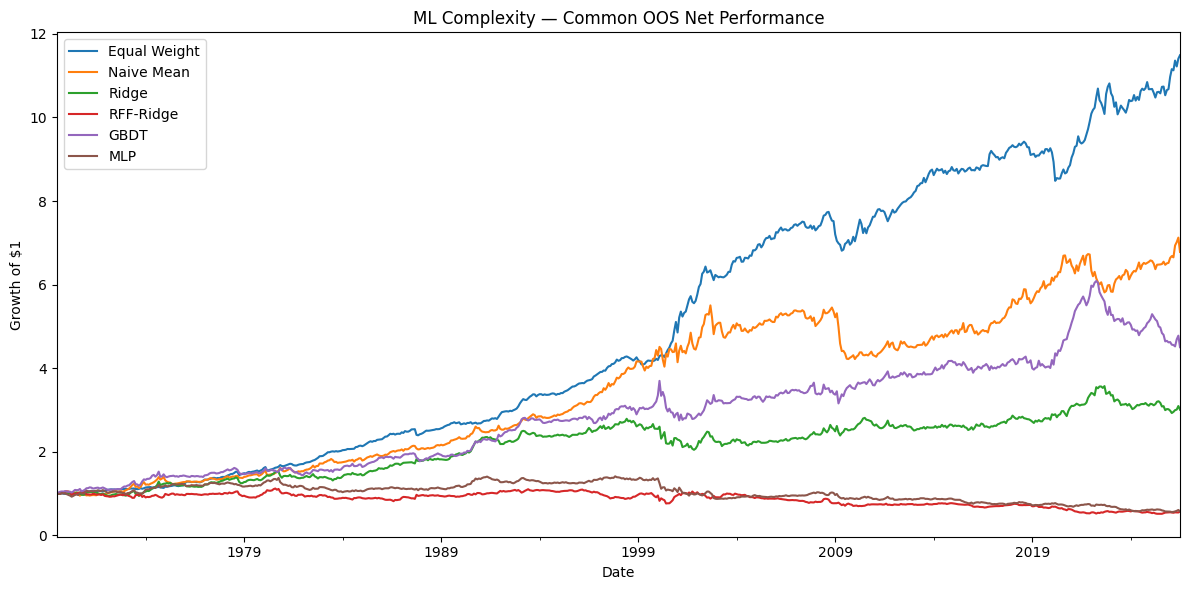

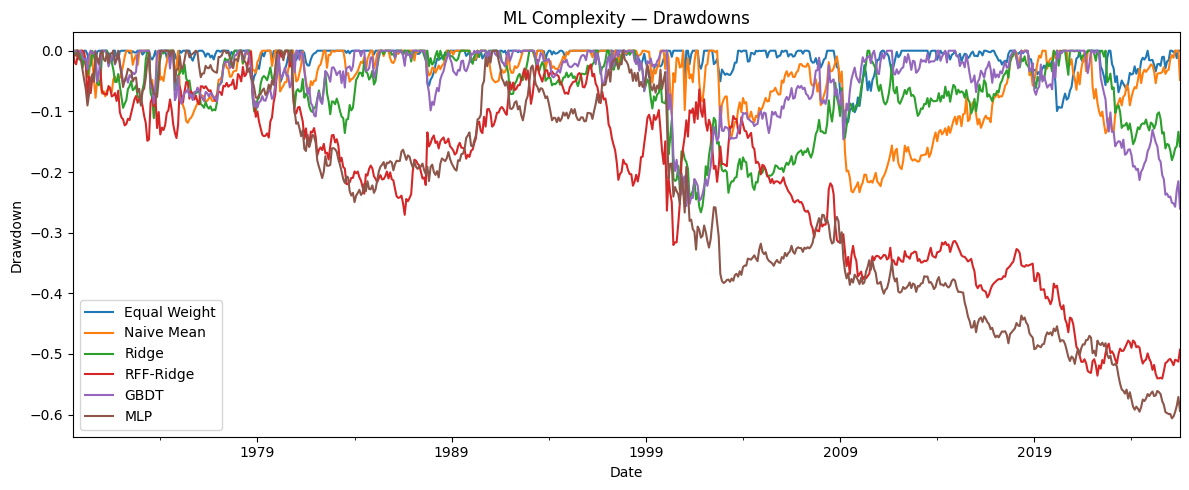

Model-fit failures: 0


In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits
from IPython.display import display
from scipy.stats import skew
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.exceptions import ConvergenceWarning


# ============================================================
# SETTINGS
# ============================================================

TRAIN_MONTHS = 60
VOL_LOOKBACK = 12
MONTH_COVERAGE = 0.95
MIN_MONTH_OBS = 15

GROSS_LIMIT = 1.0
COST_BPS = 10
SEED = 42
N_JOBS = min(4, os.cpu_count() or 1)

RIDGE_ALPHA = 10.0

RFF_P = 600
RFF_GAMMA = 2.0
RFF_Z = 1.0
RFF_DRAWS = 5

GBDT_ITER = 200
GBDT_DEPTH = 2
GBDT_MIN_LEAF = 10
GBDT_L2 = 1.0

MLP_HIDDEN = (8,)
MLP_ALPHA = 0.1

N_BOOT = 5000
BOOT_BLOCK = 6

MODEL_NAMES = ["Equal Weight", "Naive Mean", "Ridge", "RFF-Ridge", "GBDT", "MLP"]
warnings.filterwarnings("ignore", category=ConvergenceWarning)
print(f"CPU cores: {os.cpu_count()} | Parallel workers: {N_JOBS}")


# ============================================================
# DATA
# ============================================================

def make_monthly_returns(ff6, factor_cols):
    raw = ff6[factor_cols].copy().sort_index().astype(float) / 100.0
    raw = raw[~raw.index.duplicated(keep="last")]
    rows = {}

    for period, block in raw.groupby(raw.index.to_period("M")):
        complete = block.dropna(how="any")
        if len(block) == 0 or len(complete) / len(block) < MONTH_COVERAGE or len(complete) < MIN_MONTH_OBS:
            continue
        rows[period] = (1 + complete).prod() - 1

    monthly = pd.DataFrame.from_dict(rows, orient="index")
    monthly.index = pd.PeriodIndex(monthly.index, freq="M")
    return raw, monthly.sort_index()


# ============================================================
# COMMON FEATURE SET
# Same information set for Ridge, RFF-Ridge, GBDT and MLP.
# ============================================================

def build_features(monthly):
    frames = []
    for col in monthly.columns:
        r = monthly[col]
        frames.append(pd.DataFrame({
            f"{col}_r1": r,
            f"{col}_mean3": r.rolling(3).mean(),
            f"{col}_mean6": r.rolling(6).mean(),
            f"{col}_mean12": r.rolling(12).mean(),
            f"{col}_vol3": np.sqrt(r.pow(2).rolling(3).mean()),
            f"{col}_vol6": np.sqrt(r.pow(2).rolling(6).mean()),
            f"{col}_vol12": np.sqrt(r.pow(2).rolling(12).mean())
        }))
    return pd.concat(frames, axis=1)


def build_targets(monthly):
    # Feature date t predicts next-month return scaled by volatility known at t.
    vol = np.sqrt(monthly.pow(2).rolling(VOL_LOOKBACK).mean())
    return monthly.shift(-1) / vol


# ============================================================
# PORTFOLIO MAPPING
# ============================================================

def forecast_to_weights(f):
    f = np.asarray(f, float)
    gross = np.abs(f).sum()
    return GROSS_LIMIT * f / gross if np.isfinite(gross) and gross > 1e-12 else np.zeros_like(f)


def equal_weights(n):
    return np.ones(n) / n


# ============================================================
# MODELS
# Fixed ex-ante configurations: no OOS hyperparameter tuning.
# ============================================================

def make_ridge():
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", Ridge(alpha=RIDGE_ALPHA, fit_intercept=True))
    ])


def make_gbdt():
    return HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=GBDT_ITER,
        max_depth=GBDT_DEPTH,
        min_samples_leaf=GBDT_MIN_LEAF,
        l2_regularization=GBDT_L2,
        early_stopping=False,
        random_state=SEED
    )


def make_mlp():
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=MLP_HIDDEN,
            activation="relu",
            solver="lbfgs",
            alpha=MLP_ALPHA,
            max_iter=2000,
            random_state=SEED
        ))
    ])


# ============================================================
# VoC-STYLE RANDOM FOURIER FEATURES
# This is VoC-inspired, not a claim of exact paper replication.
# ============================================================

def rff_transform(X_train, X_now, p, gamma, seed):
    if p % 2:
        raise ValueError("RFF_P must be even")

    X_train = np.asarray(X_train, float)
    X_now = np.asarray(X_now, float)
    x_mean = X_train.mean(axis=0)
    x_sd = X_train.std(axis=0, ddof=1)
    x_sd[x_sd < 1e-12] = 1.0
    Xs = (X_train - x_mean) / x_sd
    X0 = (X_now - x_mean) / x_sd

    rng = np.random.default_rng(seed)
    omega = rng.normal(size=(p // 2, Xs.shape[1]))
    A_train = gamma * (Xs @ omega.T)
    A_now = gamma * (X0 @ omega.T)
    Z_train = np.concatenate([np.sin(A_train), np.cos(A_train)], axis=1)
    Z_now = np.concatenate([np.sin(A_now), np.cos(A_now)], axis=1)

    z_mean = Z_train.mean(axis=0)
    z_sd = Z_train.std(axis=0, ddof=1)
    z_sd[z_sd < 1e-12] = 1.0
    return (Z_train - z_mean) / z_sd, (Z_now - z_mean) / z_sd


def voc_ridge_predict(Z_train, Y_train, Z_now, z):
    Z = np.asarray(Z_train, float)
    Y = np.asarray(Y_train, float)
    Z0 = np.asarray(Z_now, float)
    T = Z.shape[0]
    dual = np.linalg.solve(Z @ Z.T + T * z * np.eye(T), Y)
    return (Z0 @ Z.T @ dual).ravel()


def rff_ridge_predict(X_train, Y_train, X_now):
    preds = []
    for draw in range(RFF_DRAWS):
        Z_train, Z_now = rff_transform(X_train, X_now, RFF_P, RFF_GAMMA, SEED + draw)
        preds.append(voc_ridge_predict(Z_train, Y_train, Z_now, RFF_Z))
    return np.mean(preds, axis=0)


# ============================================================
# ONE REBALANCE DATE
# ============================================================

def fit_one_date(task):
    t, next_t, X_train, Y_train, X_now, realised_next = task

    try:
        Xtr = X_train.to_numpy(float)
        Ytr = Y_train.to_numpy(float)
        X0 = X_now.to_numpy(float)
        forecasts = {"Naive Mean": Ytr.mean(axis=0)}

        with threadpool_limits(1):
            ridge_pred = []
            for j in range(Ytr.shape[1]):
                model = make_ridge()
                model.fit(Xtr, Ytr[:, j])
                ridge_pred.append(model.predict(X0)[0])
            forecasts["Ridge"] = np.asarray(ridge_pred)

            forecasts["RFF-Ridge"] = rff_ridge_predict(Xtr, Ytr, X0)

            gbdt_pred = []
            for j in range(Ytr.shape[1]):
                model = make_gbdt()
                model.fit(Xtr, Ytr[:, j])
                gbdt_pred.append(model.predict(X0)[0])
            forecasts["GBDT"] = np.asarray(gbdt_pred)

            mlp_pred = []
            for j in range(Ytr.shape[1]):
                model = make_mlp()
                model.fit(Xtr, Ytr[:, j])
                mlp_pred.append(model.predict(X0)[0])
            forecasts["MLP"] = np.asarray(mlp_pred)

        for name, pred in forecasts.items():
            if not np.isfinite(pred).all():
                raise ValueError(f"{name}: non-finite forecast")

        weights = {"Equal Weight": equal_weights(Ytr.shape[1])}
        weights.update({name: forecast_to_weights(pred) for name, pred in forecasts.items()})

        return {
            "success": True, "Fit Period": t, "Date": next_t.to_timestamp("M"),
            "Forecasts": forecasts, "Weights": weights,
            "Realised": np.asarray(realised_next, float), "Error": None
        }
    except Exception as e:
        return {
            "success": False, "Fit Period": t, "Date": next_t.to_timestamp("M"),
            "Forecasts": None, "Weights": None, "Realised": None, "Error": repr(e)
        }


# ============================================================
# PARALLEL STRICT WALK-FORWARD
# ============================================================

def run_ml_comparison_parallel(ff6, FACTOR_COLS, n_jobs=N_JOBS):
    raw, monthly = make_monthly_returns(ff6, FACTOR_COLS)
    X = build_features(monthly)
    Y = build_targets(monthly)
    tasks = []

    for t in monthly.index:
        next_t = t + 1
        if next_t not in monthly.index or t not in X.index:
            continue

        X_now = X.loc[[t]]
        if X_now.isna().any(axis=None):
            continue

        # Exactly 60 consecutive feature/label dates ending at t-1.
        train_dates = pd.period_range(end=t - 1, periods=TRAIN_MONTHS, freq="M")
        if not train_dates.isin(X.index).all() or not train_dates.isin(Y.index).all():
            continue

        X_train = X.reindex(train_dates)
        Y_train = Y.reindex(train_dates)
        if X_train.isna().any(axis=None) or Y_train.isna().any(axis=None):
            continue

        realised_next = monthly.loc[next_t]
        if realised_next.isna().any():
            continue

        tasks.append((t, next_t, X_train.copy(), Y_train.copy(), X_now.copy(), realised_next.to_numpy(float)))

    print(f"Valid common OOS dates: {len(tasks)}")
    if not tasks:
        raise RuntimeError("No valid common OOS dates. Check history, missing months and FACTOR_COLS.")

    fitted_all = Parallel(n_jobs=n_jobs, backend="loky", batch_size=1, verbose=5)(
        delayed(fit_one_date)(task) for task in tasks
    )
    failures = [x for x in fitted_all if not x["success"]]
    fitted = sorted([x for x in fitted_all if x["success"]], key=lambda x: x["Fit Period"])

    print(f"Successful dates: {len(fitted)} | Failed dates: {len(failures)}")
    if not fitted:
        display(pd.DataFrame(failures))
        raise RuntimeError("All model fits failed")

    previous = {name: None for name in MODEL_NAMES}
    previous_period = None
    return_rows, turnover_rows, forecast_rows = {}, {}, {}

    for result in fitted:
        fit_period = result["Fit Period"]
        if previous_period is None or fit_period != previous_period + 1:
            previous = {name: None for name in MODEL_NAMES}

        ret_row, turn_row = {}, {}
        for name in MODEL_NAMES:
            w = np.asarray(result["Weights"][name], float)
            turnover = 0.0 if previous[name] is None else 0.5 * np.abs(w - previous[name]).sum()
            ret_row[name] = w @ result["Realised"] - COST_BPS / 10_000 * turnover
            turn_row[name] = turnover
            previous[name] = w.copy()

        forecast_row = {
            f"{model_name}_{factor}": pred[j]
            for model_name, pred in result["Forecasts"].items()
            for j, factor in enumerate(FACTOR_COLS)
        }

        return_rows[result["Date"]] = ret_row
        turnover_rows[result["Date"]] = turn_row
        forecast_rows[result["Date"]] = forecast_row
        previous_period = fit_period

    returns = pd.DataFrame.from_dict(return_rows, orient="index").sort_index()
    turnovers = pd.DataFrame.from_dict(turnover_rows, orient="index").sort_index()
    forecasts = pd.DataFrame.from_dict(forecast_rows, orient="index").sort_index()
    returns.index.name = turnovers.index.name = forecasts.index.name = "Date"

    common = returns.dropna(how="any").index
    return returns.loc[common], turnovers.loc[common], forecasts.loc[common], failures, raw, monthly, X, Y


# ============================================================
# PERFORMANCE
# ============================================================

def stationary_bootstrap(x, n_boot=N_BOOT, mean_block=BOOT_BLOCK, seed=SEED):
    x = np.asarray(x, float)
    n = len(x)
    rng = np.random.default_rng(seed)
    p = 1 / mean_block
    boot = np.empty((n_boot, n))
    for b in range(n_boot):
        j = rng.integers(n)
        for i in range(n):
            j = rng.integers(n) if i == 0 or rng.random() < p else (j + 1) % n
            boot[b, i] = x[j]
    return boot


def bootstrap_sharpe_ci(r):
    x = pd.Series(r).dropna().to_numpy(float)
    if len(x) < 2:
        return np.nan, np.nan
    boot = stationary_bootstrap(x)
    sd = boot.std(axis=1, ddof=1)
    sr = np.sqrt(12) * boot.mean(axis=1) / sd
    sr = sr[np.isfinite(sr)]
    return np.quantile(sr, [0.025, 0.975]) if len(sr) else (np.nan, np.nan)


def max_drawdown(r):
    wealth = (1 + r).cumprod()
    return (wealth / wealth.cummax() - 1).min()


def performance_table(returns, turnovers):
    rows = []
    for name in returns.columns:
        r = returns[name].dropna()
        n = len(r)
        sd = r.std(ddof=1)
        terminal = (1 + r).prod()
        lo, hi = bootstrap_sharpe_ci(r)
        rows.append({
            "Strategy": name,
            "Arithmetic Return": 12 * r.mean(),
            "Geometric Return": terminal ** (12 / n) - 1 if terminal > 0 else np.nan,
            "Volatility": np.sqrt(12) * sd,
            "Sharpe": np.sqrt(12) * r.mean() / sd if sd > 0 else np.nan,
            "Sharpe CI Low": lo,
            "Sharpe CI High": hi,
            "Skew": skew(r, bias=False),
            "Max Drawdown": max_drawdown(r),
            "Turnover": turnovers.loc[r.index, name].mean()
        })
    return pd.DataFrame(rows).set_index("Strategy")


# ============================================================
# RUN / OUTPUT
# ============================================================

returns, turnovers, forecasts, fit_failures, ff6_decimal, monthly, feature_matrix, target_matrix = run_ml_comparison_parallel(
    ff6=ff6, FACTOR_COLS=FACTOR_COLS, n_jobs=N_JOBS
)
results = performance_table(returns, turnovers)

PERFORMANCE_FORMAT = {
    "Arithmetic Return": "{:.2%}", "Geometric Return": "{:.2%}", "Volatility": "{:.2%}",
    "Sharpe": "{:.2f}", "Sharpe CI Low": "{:.2f}", "Sharpe CI High": "{:.2f}",
    "Skew": "{:.2f}", "Max Drawdown": "{:.2%}", "Turnover": "{:.2%}"
}

display(results.style.format(PERFORMANCE_FORMAT, na_rep="—"))
print("\nDaily FF6 returns after /100")
display(ff6_decimal.describe().T[["mean", "std", "min", "max"]].style.format("{:.4f}"))
print("\nMonthly FF6 returns")
display(monthly.describe().T[["mean", "std", "min", "max"]].style.format("{:.4f}"))
print("\nStrategy monthly returns")
display(returns.describe().T[["mean", "std", "min", "max"]].style.format("{:.4f}"))
print(f"Common OOS: {returns.index.min().date()} to {returns.index.max().date()} | {len(returns)} months")

wealth = (1 + returns).cumprod()
wealth.plot(figsize=(12, 6), title="ML Complexity — Common OOS Net Performance")
plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

(wealth / wealth.cummax() - 1).plot(figsize=(12, 5), title="ML Complexity — Drawdowns")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

print(f"Model-fit failures: {len(fit_failures)}")
if fit_failures:
    display(pd.DataFrame(fit_failures)[["Date", "Fit Period", "Error"]])


# HMM

HMM. A 2-state full-covariance Gaussian HMM is refit monthly on the previous five calendar years of daily returns, using five random restarts and retaining the highest-likelihood valid fit. The old implementation projected only one daily transition \(p_tA\) and then used daily emission moments for a portfolio held for an entire month. That horizon mismatch is fixed: the new code starts from the next-day filtered state probabilities, simulates 21 trading days of state transitions and multivariate emissions, compounds those daily returns, and obtains next-month conditional moments for each possible next state. Hard-state, probability-weighted-moment, and probability-weighted-state-portfolio constructions all use those same monthly-horizon conditional distributions. Trailing IV/MVO remain the benchmarks. Fits are parallel by month, costs/turnover are sequential, and failed-date gaps reset the turnover path rather than pretending two nonadjacent rebalances were consecutive.

## Daily

CPU cores: 2 | Parallel workers: 2
Valid rebalance dates: 724


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  14 tasks      | elapsed:    9.2s
[Parallel(n_jobs=2)]: Done  68 tasks      | elapsed:   17.4s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:   27.9s
[Parallel(n_jobs=2)]: Done 284 tasks      | elapsed:   43.3s
[Parallel(n_jobs=2)]: Done 446 tasks      | elapsed:  1.1min
[Parallel(n_jobs=2)]: Done 644 tasks      | elapsed:  1.6min
[Parallel(n_jobs=2)]: Done 724 out of 724 | elapsed:  1.8min finished


Successful dates: 724 | Failed dates: 0


,Arithmetic Return,Geometric Return,Volatility,Sharpe,Sharpe CI Low,Sharpe CI High,Skew,Max Drawdown,Turnover
Strategy,,,,,,,,,
Equal Weight,4.36%,4.37%,4.08%,1.07,0.79,1.37,-0.29,-12.00%,0.00%
Trailing IV,4.02%,4.02%,3.78%,1.06,0.79,1.36,0.55,-11.35%,0.43%
Trailing MVO,3.20%,3.13%,4.77%,0.67,0.44,0.93,-0.17,-11.65%,8.22%
HMM Hard IV,4.15%,4.15%,3.90%,1.06,0.79,1.35,0.21,-10.89%,1.08%
HMM Hard MVO,1.43%,1.31%,5.05%,0.28,0.06,0.52,-0.42,-15.17%,15.64%
HMM Weighted-Moment IV,4.16%,4.16%,3.90%,1.07,0.79,1.36,0.21,-10.86%,1.03%
HMM Weighted-Moment MVO,1.42%,1.30%,4.98%,0.28,0.06,0.52,-0.53,-14.01%,14.92%
HMM Weighted-Portfolio IV,4.16%,4.16%,3.90%,1.07,0.79,1.36,0.22,-10.80%,1.01%
HMM Weighted-Portfolio MVO,1.44%,1.33%,4.92%,0.29,0.06,0.53,-0.49,-13.95%,14.55%



Daily FF6 returns after /100


...


Monthly FF6 returns


,mean,std,min,max
Mkt-RF,0.0060,0.0445,-0.2309,0.1603
SMB,0.0015,0.0302,-0.1456,0.1835
HML,0.0032,0.0297,-0.1464,0.1376
RMW,0.0027,0.0228,-0.1576,0.1532
CMA,0.0026,0.0208,-0.0691,0.1020
Mom,0.0063,0.0418,-0.2677,0.1894



Strategy monthly returns


,mean,std,min,max
Equal Weight,0.0036,0.0118,-0.0533,0.0740
Trailing IV,0.0033,0.0109,-0.0499,0.0821
Trailing MVO,0.0027,0.0138,-0.0963,0.0923
HMM Hard IV,0.0035,0.0113,-0.0486,0.0794
HMM Hard MVO,0.0012,0.0146,-0.0935,0.0897
HMM Weighted-Moment IV,0.0035,0.0113,-0.0484,0.0791
HMM Weighted-Moment MVO,0.0012,0.0144,-0.0927,0.0766
HMM Weighted-Portfolio IV,0.0035,0.0113,-0.0486,0.0798
HMM Weighted-Portfolio MVO,0.0012,0.0142,-0.0929,0.0787


Common OOS: 1966-04-30 to 2026-07-31 | 724 months


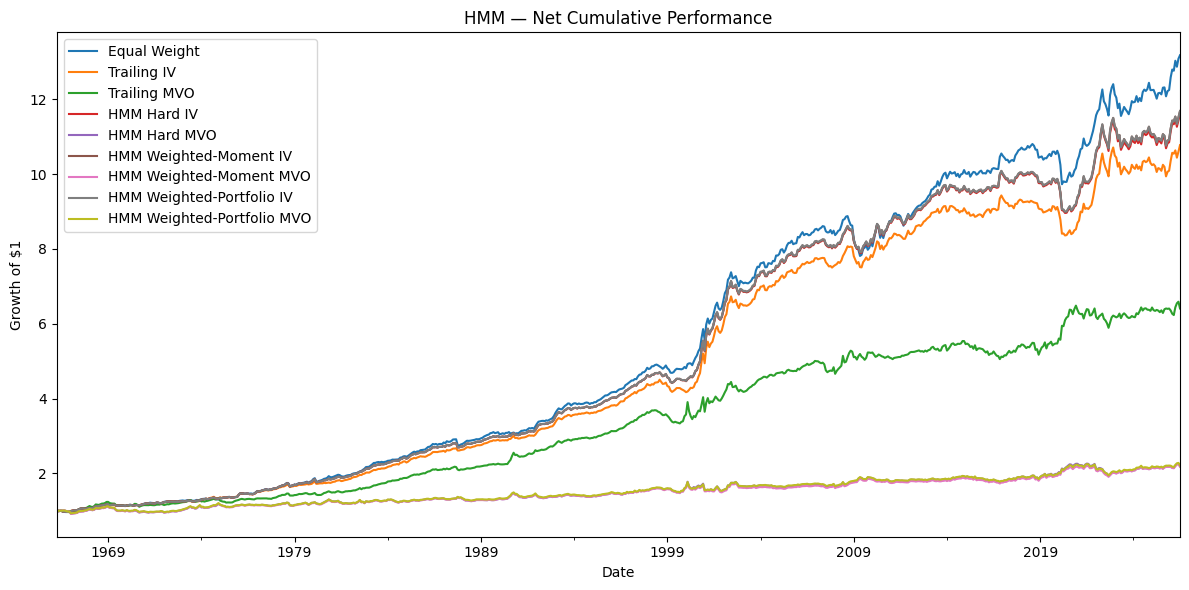

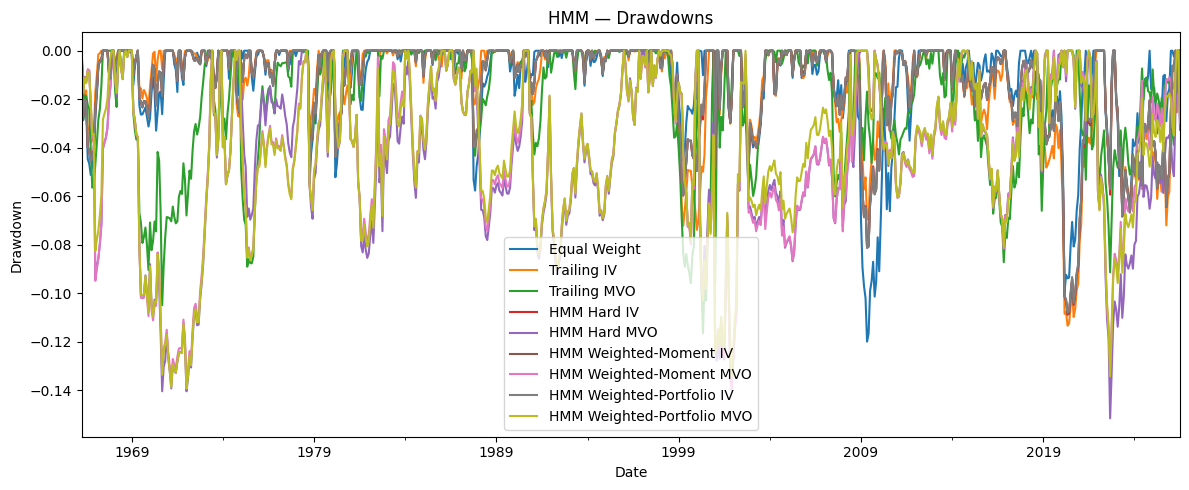


HMM fit diagnostics


,Best LogLik,Successful Restarts,Best Iterations,State Prob Max,State Entropy
count,724.000000,724.0,724.000000,724.000000,7.240000e+02
mean,18020.015465,5.0,13.664365,0.952317,1.436207e-01
std,1242.960240,0.0,31.962925,0.090799,1.516529e-01
min,15014.659337,5.0,2.000000,0.503995,1.036983e-26
25%,17286.247138,5.0,2.000000,0.971438,6.371115e-02
50%,18330.632432,5.0,2.000000,0.982034,9.001240e-02
75%,18954.654219,5.0,2.000000,0.988292,1.297088e-01
max,20317.772704,5.0,367.000000,1.000000,6.931153e-01


HMM fit failures: 0


In [ ]:
import os
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits
from IPython.display import display
from scipy.stats import skew
from sklearn.covariance import LedoitWolf
from hmmlearn.hmm import GaussianHMM


# ============================================================
# SETTINGS
# ============================================================

WINDOW_YEARS = 5
MIN_WINDOW_COVERAGE = 0.90
MIN_WINDOW_OBS = int(252 * WINDOW_YEARS * MIN_WINDOW_COVERAGE)
MAX_GAP_DAYS = 10

N_STATES = 2
N_RESTARTS = 5
FORECAST_DAYS = 21
HMM_SIMULATIONS_PER_STATE = 3000
SEED = 42

GROSS_LIMIT = 1.0
COST_BPS = 10

N_BOOT = 5000
BOOT_BLOCK = 6
N_JOBS = min(4, os.cpu_count() or 1)

logging.getLogger("hmmlearn.base").setLevel(logging.ERROR)
print(f"CPU cores: {os.cpu_count()} | Parallel workers: {N_JOBS}")


# ============================================================
# PORTFOLIO RULES
# ============================================================

def normalize_long(w):
    w = np.maximum(np.asarray(w, float), 0)
    return w / w.sum() if w.sum() > 1e-12 else np.ones(len(w)) / len(w)


def normalize_gross(w, gross_limit=GROSS_LIMIT):
    w = np.asarray(w, float)
    gross = np.abs(w).sum()
    return gross_limit * w / gross if np.isfinite(gross) and gross > 1e-12 else np.zeros_like(w)


def iv_weights(Sigma):
    vol = np.sqrt(np.maximum(np.diag(Sigma), 1e-12))
    return normalize_long(1 / vol)


def mvo_weights(mu, Sigma):
    mu = np.asarray(mu, float)
    Sigma = np.asarray(Sigma, float) + 1e-10 * np.eye(len(mu))
    try:
        z = np.linalg.solve(Sigma, mu)
    except np.linalg.LinAlgError:
        z = np.linalg.pinv(Sigma) @ mu
    return normalize_gross(z)


def trailing_moments(X):
    X = np.asarray(X, float)
    return X.mean(axis=0), LedoitWolf().fit(X).covariance_


# ============================================================
# HMM FIT
# ============================================================

def fit_hmm(X, date=None):
    X = np.asarray(X, float)
    best_model, best_ll, n_success = None, -np.inf, 0

    for j in range(N_RESTARTS):
        model = GaussianHMM(
            n_components=N_STATES,
            covariance_type="full",
            n_iter=1000,
            tol=1e-5,
            min_covar=1e-6,
            random_state=SEED + j
        )
        try:
            model.fit(X)
            ll = model.score(X)
            finite = (
                np.isfinite(ll)
                and np.isfinite(model.means_).all()
                and np.isfinite(model.covars_).all()
                and np.isfinite(model.transmat_).all()
            )
            if not finite:
                continue
            n_success += 1
            if ll > best_ll:
                best_model, best_ll = model, ll
        except Exception:
            continue

    if best_model is None:
        raise RuntimeError(f"All HMM restarts failed at {date}")

    diagnostic = {
        "Fit Date": date,
        "Best LogLik": best_ll,
        "Successful Restarts": n_success,
        "Total Restarts": N_RESTARTS,
        "Best Converged": best_model.monitor_.converged,
        "Best Iterations": best_model.monitor_.iter
    }
    return best_model, diagnostic


def next_state_probs(model, X):
    # Endpoint posterior equals the filtered probability because there are no future observations beyond t.
    p_t = model.predict_proba(np.asarray(X, float))[-1]
    q1 = p_t @ model.transmat_
    return q1 / q1.sum()


# ============================================================
# MULTI-DAY HMM PREDICTIVE MOMENTS
# Simulate exact compounded next-month factor returns conditional
# on the next-day state. The same conditional moments feed all
# three HMM conventions.
# ============================================================

def conditional_horizon_moments(transmat, mus, covs, date=None, horizon=FORECAST_DAYS, n_sim=HMM_SIMULATIONS_PER_STATE):
    A = np.asarray(transmat, float)
    M = np.asarray(mus, float)
    C = np.asarray(covs, float)
    K, n = M.shape
    horizon_mu = np.zeros((K, n))
    horizon_cov = np.zeros((K, n, n))
    date_seed = pd.Timestamp(date).toordinal() if date is not None else 0

    for initial_state in range(K):
        rng = np.random.default_rng(SEED + 1009 * initial_state + date_seed)
        states = np.full(n_sim, initial_state, dtype=int)
        wealth = np.ones((n_sim, n))

        for h in range(horizon):
            daily = np.empty((n_sim, n))
            for k in range(K):
                mask = states == k
                m = int(mask.sum())
                if m:
                    daily[mask] = rng.multivariate_normal(M[k], C[k], size=m)

            # Gaussian emissions can technically generate r <= -1; clipping only
            # prevents an impossible simple-return compounding path.
            daily = np.maximum(daily, -0.999999)
            wealth *= 1 + daily

            if h < horizon - 1:
                next_states = np.empty_like(states)
                for k in range(K):
                    mask = states == k
                    m = int(mask.sum())
                    if m:
                        next_states[mask] = rng.choice(K, size=m, p=A[k])
                states = next_states

        monthly_returns = wealth - 1
        horizon_mu[initial_state] = monthly_returns.mean(axis=0)
        horizon_cov[initial_state] = np.cov(monthly_returns, rowvar=False, ddof=1)

    return horizon_mu, horizon_cov


def mixture_moments(q, mus, covs):
    mu = np.sum(q[:, None] * mus, axis=0)
    Sigma = np.zeros_like(covs[0])
    for k in range(len(q)):
        d = (mus[k] - mu)[:, None]
        Sigma += q[k] * (covs[k] + d @ d.T)
    return mu, 0.5 * (Sigma + Sigma.T)


# ============================================================
# PORTFOLIOS AT ONE REBALANCE DATE
# ============================================================

def primary_weights(train, date=None):
    X = train.to_numpy(float)
    n = X.shape[1]
    weights = {"Equal Weight": np.ones(n) / n}

    # Trailing daily moments. Multiplying both mean and covariance by a common horizon
    # leaves IV/MVO weights unchanged under the iid trailing benchmark.
    mu_trail, Sigma_trail = trailing_moments(X)
    weights["Trailing IV"] = iv_weights(Sigma_trail)
    weights["Trailing MVO"] = mvo_weights(mu_trail, Sigma_trail)

    model, diagnostic = fit_hmm(X, date=date)
    q1 = next_state_probs(model, X)
    mus = np.asarray(model.means_, float)
    covs = np.asarray(model.covars_, float)
    A = np.asarray(model.transmat_, float)

    diagnostic.update({
        "State Prob Max": q1.max(),
        "State Entropy": -np.sum(q1 * np.log(np.maximum(q1, 1e-12)))
    })

    # Forecast compounded next-month return moments conditional on S_(t+1)=k.
    horizon_mu, horizon_cov = conditional_horizon_moments(A, mus, covs, date=date)

    # 1. Hard/MAP next-day state.
    k_star = int(np.argmax(q1))
    weights["HMM Hard IV"] = iv_weights(horizon_cov[k_star])
    weights["HMM Hard MVO"] = mvo_weights(horizon_mu[k_star], horizon_cov[k_star])

    # 2. Probability-weighted predictive monthly moments.
    mu_mix, Sigma_mix = mixture_moments(q1, horizon_mu, horizon_cov)
    weights["HMM Weighted-Moment IV"] = iv_weights(Sigma_mix)
    weights["HMM Weighted-Moment MVO"] = mvo_weights(mu_mix, Sigma_mix)

    # 3. Probability-weighted state portfolios.
    state_iv = np.asarray([iv_weights(horizon_cov[k]) for k in range(N_STATES)])
    state_mvo = np.asarray([mvo_weights(horizon_mu[k], horizon_cov[k]) for k in range(N_STATES)])
    weights["HMM Weighted-Portfolio IV"] = (q1[:, None] * state_iv).sum(axis=0)
    # Intentionally not re-normalised: disagreement across state portfolios can reduce gross exposure.
    weights["HMM Weighted-Portfolio MVO"] = (q1[:, None] * state_mvo).sum(axis=0)

    return weights, diagnostic


# ============================================================
# DATA / ROLLING WINDOW
# ============================================================

def valid_training_window(raw, t):
    start = t - pd.DateOffset(years=WINDOW_YEARS)
    block = raw.loc[(raw.index > start) & (raw.index <= t)]
    if block.empty:
        return None

    valid = block.notna().all(axis=1)
    if valid.mean() < MIN_WINDOW_COVERAGE:
        return None

    train = block.loc[valid]
    if len(train) < MIN_WINDOW_OBS:
        return None

    gaps = train.index.to_series().diff().dt.days
    if len(gaps) and gaps.max() > MAX_GAP_DAYS:
        return None
    return train


def monthly_factor_returns(raw):
    rows = {}
    for period, block in raw.groupby(raw.index.to_period("M")):
        valid = block.dropna(how="any")
        if len(block) == 0 or len(valid) / len(block) < 0.95 or len(valid) < 15:
            continue
        rows[period] = (1 + valid).prod() - 1

    monthly = pd.DataFrame.from_dict(rows, orient="index")
    monthly.index = pd.PeriodIndex(monthly.index, freq="M")
    return monthly.sort_index()


# ============================================================
# PARALLEL WALK-FORWARD
# ============================================================

def _fit_one_rebalance(task):
    t, period, result_date, train, r_next = task
    logging.getLogger("hmmlearn.base").setLevel(logging.ERROR)
    try:
        with threadpool_limits(1):
            weights, diagnostic = primary_weights(train, date=t)
        return {
            "success": True, "Period": period, "Date": result_date, "Fit Date": t,
            "Weights": weights, "Realised Return": r_next, "Diagnostic": diagnostic, "Error": None
        }
    except Exception as e:
        return {
            "success": False, "Period": period, "Date": result_date, "Fit Date": t,
            "Weights": None, "Realised Return": None, "Diagnostic": None, "Error": repr(e)
        }


def run_primary_parallel(ff6, FACTOR_COLS, n_jobs=N_JOBS):
    raw = ff6[FACTOR_COLS].copy().sort_index().astype(float) / 100.0
    raw = raw[~raw.index.duplicated(keep="last")]
    monthly = monthly_factor_returns(raw)
    periods = sorted(monthly.index)

    tasks = []
    for i in range(len(periods) - 1):
        period, next_period = periods[i], periods[i + 1]
        if next_period != period + 1:
            continue

        current_block = raw[raw.index.to_period("M") == period]
        if current_block.empty:
            continue

        t = current_block.index[-1]
        train = valid_training_window(raw, t)
        if train is None:
            continue

        tasks.append((t, period, next_period.to_timestamp("M"), train.copy(), monthly.loc[next_period].to_numpy(float)))

    print(f"Valid rebalance dates: {len(tasks)}")
    if not tasks:
        raise RuntimeError("No valid rebalance dates. Check history, coverage and FACTOR_COLS.")

    fitted_all = Parallel(n_jobs=n_jobs, backend="loky", batch_size=1, verbose=5)(
        delayed(_fit_one_rebalance)(task) for task in tasks
    )
    failures = [x for x in fitted_all if not x["success"]]
    fitted = sorted([x for x in fitted_all if x["success"]], key=lambda x: x["Period"])

    print(f"Successful dates: {len(fitted)} | Failed dates: {len(failures)}")
    if not fitted:
        display(pd.DataFrame(failures)[["Date", "Fit Date", "Error"]])
        raise RuntimeError("All HMM fits failed.")

    previous, previous_period = None, None
    return_rows, turnover_rows, diagnostic_rows = {}, {}, {}

    for result in fitted:
        period = result["Period"]
        if previous_period is None or period != previous_period + 1:
            previous = {name: None for name in result["Weights"]}

        ret_row, turn_row = {}, {}
        for name, w in result["Weights"].items():
            w = np.asarray(w, float)
            turnover = 0.0 if previous[name] is None else 0.5 * np.abs(w - previous[name]).sum()
            ret_row[name] = w @ result["Realised Return"] - COST_BPS / 10_000 * turnover
            turn_row[name] = turnover
            previous[name] = w.copy()

        return_rows[result["Date"]] = ret_row
        turnover_rows[result["Date"]] = turn_row
        diagnostic_rows[result["Date"]] = result["Diagnostic"]
        previous_period = period

    returns = pd.DataFrame.from_dict(return_rows, orient="index").sort_index()
    turnovers = pd.DataFrame.from_dict(turnover_rows, orient="index").sort_index()
    diagnostics = pd.DataFrame.from_dict(diagnostic_rows, orient="index").sort_index()
    returns.index.name = turnovers.index.name = diagnostics.index.name = "Date"

    common = returns.dropna(how="any").index
    return returns.loc[common], turnovers.loc[common], diagnostics.loc[common], failures, raw, monthly


# ============================================================
# PERFORMANCE
# ============================================================

def stationary_bootstrap(x, n_boot=N_BOOT, mean_block=BOOT_BLOCK, seed=SEED):
    x = np.asarray(x, float)
    n = len(x)
    rng = np.random.default_rng(seed)
    p = 1 / mean_block
    boot = np.empty((n_boot, n))
    for b in range(n_boot):
        j = rng.integers(n)
        for i in range(n):
            j = rng.integers(n) if i == 0 or rng.random() < p else (j + 1) % n
            boot[b, i] = x[j]
    return boot


def bootstrap_sharpe_ci(r):
    x = pd.Series(r).dropna().to_numpy(float)
    if len(x) < 2:
        return np.nan, np.nan
    boot = stationary_bootstrap(x)
    sd = boot.std(axis=1, ddof=1)
    sr = np.sqrt(12) * boot.mean(axis=1) / sd
    sr = sr[np.isfinite(sr)]
    return np.quantile(sr, [0.025, 0.975]) if len(sr) else (np.nan, np.nan)


def max_drawdown(r):
    wealth = (1 + r).cumprod()
    return (wealth / wealth.cummax() - 1).min()


def performance_table(returns, turnovers):
    rows = []
    for strategy in returns.columns:
        r = returns[strategy].dropna()
        n = len(r)
        sd = r.std(ddof=1)
        terminal = (1 + r).prod()
        lo, hi = bootstrap_sharpe_ci(r)
        rows.append({
            "Strategy": strategy,
            "Arithmetic Return": 12 * r.mean(),
            "Geometric Return": terminal ** (12 / n) - 1 if terminal > 0 else np.nan,
            "Volatility": np.sqrt(12) * sd,
            "Sharpe": np.sqrt(12) * r.mean() / sd if sd > 0 else np.nan,
            "Sharpe CI Low": lo,
            "Sharpe CI High": hi,
            "Skew": skew(r, bias=False),
            "Max Drawdown": max_drawdown(r),
            "Turnover": turnovers.loc[r.index, strategy].mean()
        })
    return pd.DataFrame(rows).set_index("Strategy")


# ============================================================
# RUN / OUTPUT
# ============================================================

returns, turnovers, fit_diagnostics, fit_failures, ff6_decimal, monthly = run_primary_parallel(
    ff6=ff6, FACTOR_COLS=FACTOR_COLS, n_jobs=N_JOBS
)
results = performance_table(returns, turnovers)

PERFORMANCE_FORMAT = {
    "Arithmetic Return": "{:.2%}", "Geometric Return": "{:.2%}", "Volatility": "{:.2%}",
    "Sharpe": "{:.2f}", "Sharpe CI Low": "{:.2f}", "Sharpe CI High": "{:.2f}",
    "Skew": "{:.2f}", "Max Drawdown": "{:.2%}", "Turnover": "{:.2%}"
}

display(results.style.format(PERFORMANCE_FORMAT, na_rep="—"))
print("\nDaily FF6 returns after /100")
display(ff6_decimal.describe().T[["mean", "std", "min", "max"]].style.format("{:.4f}"))
print("\nMonthly FF6 returns")
display(monthly.describe().T[["mean", "std", "min", "max"]].style.format("{:.4f}"))
print("\nStrategy monthly returns")
display(returns.describe().T[["mean", "std", "min", "max"]].style.format("{:.4f}"))
print(f"Common OOS: {returns.index.min().date()} to {returns.index.max().date()} | {len(returns)} months")

wealth = (1 + returns).cumprod()
wealth.plot(figsize=(12, 6), title="HMM — Net Cumulative Performance")
plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

(wealth / wealth.cummax() - 1).plot(figsize=(12, 5), title="HMM — Drawdowns")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

print("\nHMM fit diagnostics")
display(fit_diagnostics[["Best LogLik", "Successful Restarts", "Best Converged", "Best Iterations", "State Prob Max", "State Entropy"]].describe())
print(f"HMM fit failures: {len(fit_failures)}")
if fit_failures:
    display(pd.DataFrame(fit_failures)[["Date", "Fit Date", "Error"]])


## Monthly

CPU cores: 2 | Parallel workers: 2
Valid monthly rebalance dates: 697


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  14 tasks      | elapsed:    0.8s
[Parallel(n_jobs=2)]: Done  68 tasks      | elapsed:    3.8s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:   10.2s
[Parallel(n_jobs=2)]: Done 284 tasks      | elapsed:   16.9s
[Parallel(n_jobs=2)]: Done 446 tasks      | elapsed:   27.7s
[Parallel(n_jobs=2)]: Done 644 tasks      | elapsed:   41.5s
[Parallel(n_jobs=2)]: Done 697 out of 697 | elapsed:   46.4s finished


Successful dates: 697 | Failed dates: 0


,Arithmetic Return,Geometric Return,Volatility,Sharpe,Sharpe CI Low,Sharpe CI High,Skew,Max Drawdown,Turnover
Strategy,,,,,,,,,
Equal Weight,4.32%,4.32%,4.06%,1.06,0.79,1.39,-0.29,-12.00%,0.00%
Trailing IV,3.95%,3.95%,3.75%,1.05,0.78,1.37,0.19,-9.97%,0.44%
Trailing MVO,3.54%,3.49%,4.51%,0.79,0.54,1.07,-0.63,-16.56%,5.44%
HMM Hard IV,4.01%,4.01%,3.76%,1.06,0.79,1.38,0.20,-9.93%,2.13%
HMM Hard MVO,1.81%,1.72%,4.45%,0.41,0.15,0.68,-0.44,-22.00%,23.18%
HMM Weighted-Moment IV,3.98%,3.98%,3.77%,1.05,0.78,1.37,0.14,-10.05%,1.27%
HMM Weighted-Moment MVO,1.38%,1.28%,4.67%,0.30,0.06,0.55,-0.97,-15.36%,16.98%
HMM Weighted-Portfolio IV,4.02%,4.02%,3.76%,1.07,0.79,1.38,0.18,-9.90%,1.86%
HMM Weighted-Portfolio MVO,1.66%,1.58%,4.15%,0.40,0.15,0.67,-0.34,-16.98%,20.65%



HMM FIT / ECONOMIC-SEPARATION DIAGNOSTICS


,count,mean,std,min,25%,50%,75%,max
Best LogLik,697.0,868.098282,59.070665,6.917124e+02,833.772478,875.162673,909.511410,1059.017829
Successful Restarts,697.0,5.000000,0.000000,5.000000e+00,5.000000,5.000000,5.000000,5.000000
Best Iterations,697.0,7.043042,10.804208,2.000000e+00,2.000000,5.000000,8.000000,175.000000
State Prob Max,697.0,0.936928,0.086639,5.000000e-01,0.943793,0.963636,0.980670,1.000000
State Entropy,697.0,0.194456,0.149396,1.963296e-266,0.095421,0.156210,0.216402,0.693147
Mean Persistence,697.0,0.666887,0.142164,2.614793e-01,0.541159,0.673482,0.780938,0.991459
State Mean Distance,697.0,0.106804,0.047947,2.077566e-02,0.068069,0.092589,0.148484,0.269553
State Cov Distance,697.0,0.019355,0.014699,1.973632e-03,0.011736,0.016361,0.024068,0.188593
State IV Weight L1,697.0,0.174838,0.049104,4.239068e-02,0.139672,0.170789,0.210136,0.344436
State MVO Weight L1,697.0,1.408848,0.376608,3.558254e-01,1.123742,1.451867,1.713647,2.000000


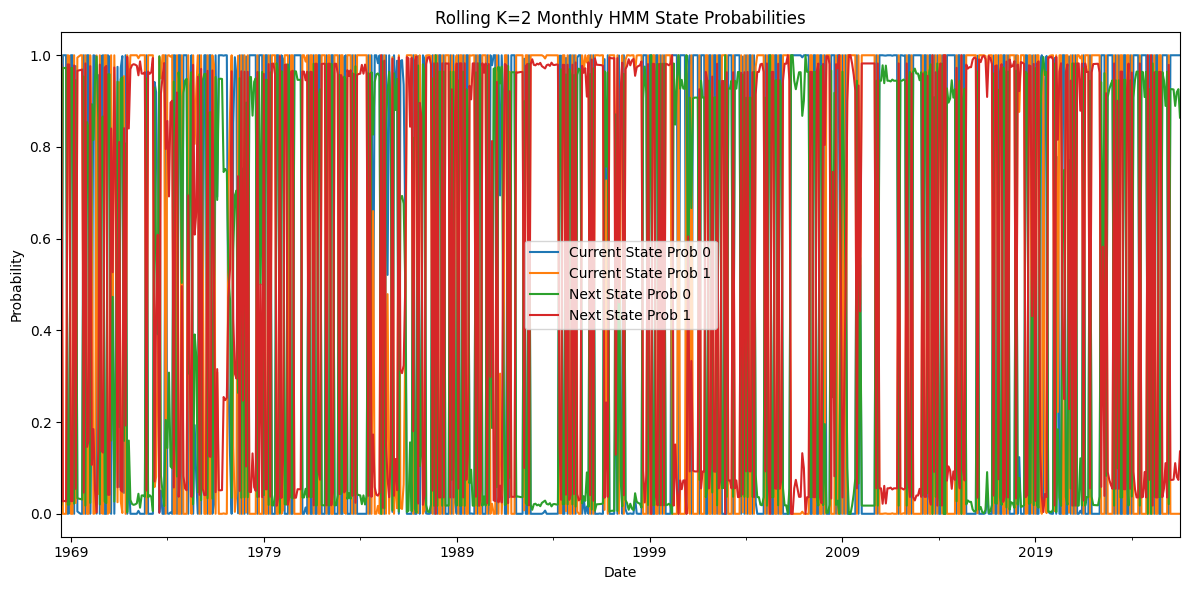

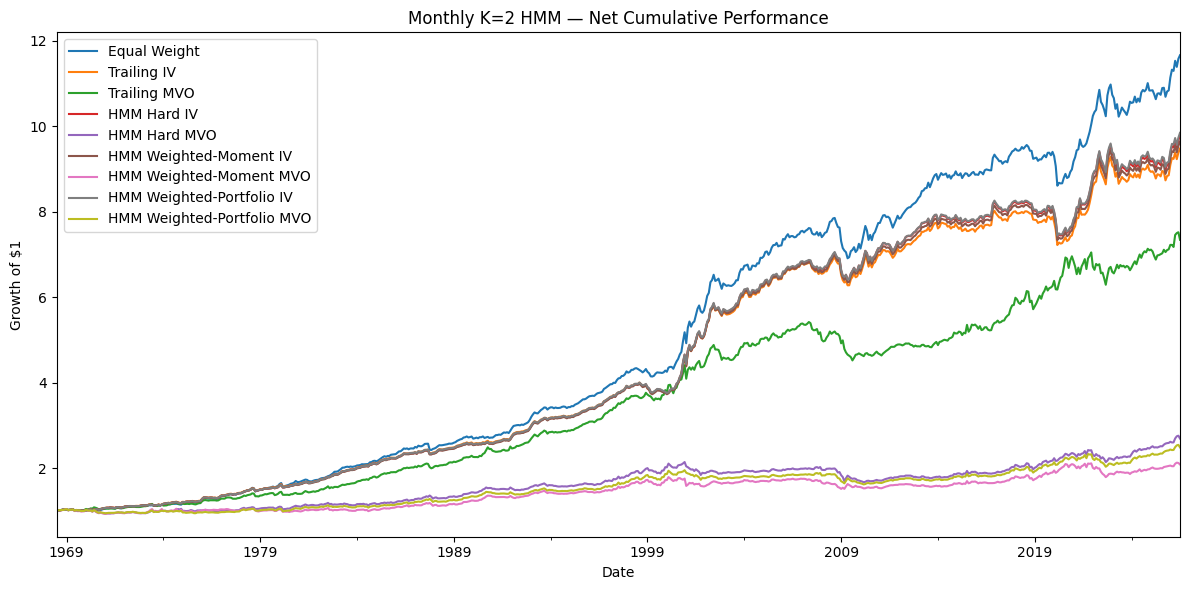

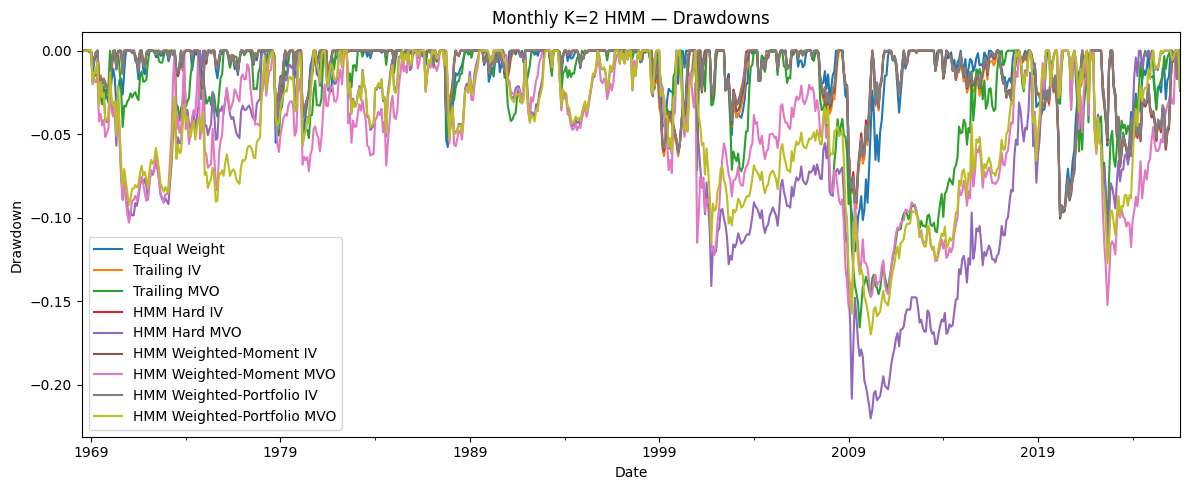


HMM PORTFOLIO WEIGHT DIFFERENCES


,count,mean,std,min,25%,50%,75%,max
Hard vs WM IV,697.0,0.030210,0.023318,0.0,0.014909,0.024245,0.039318,0.208219
WM vs WP IV,697.0,0.024300,0.016574,0.0,0.012409,0.021357,0.033629,0.125241
Hard vs WM MVO,697.0,0.332675,0.284812,0.0,0.122729,0.250545,0.459029,1.931991
WM vs WP MVO,697.0,0.315136,0.244751,0.0,0.121264,0.245623,0.462482,1.184679


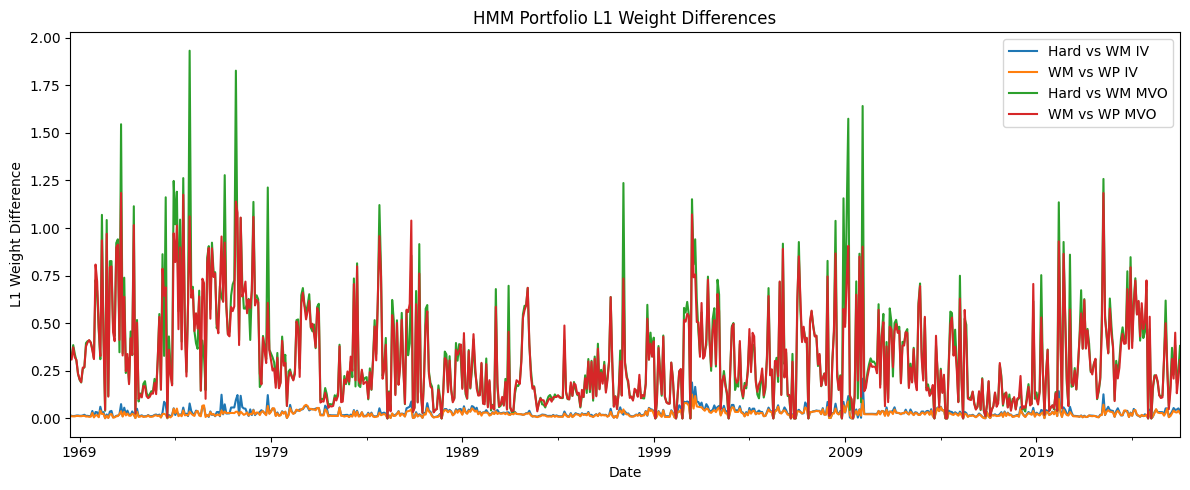


HMM fit failures: 0


In [ ]:
import os
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits
from IPython.display import display
from scipy.stats import skew
from sklearn.covariance import LedoitWolf
from hmmlearn.hmm import GaussianHMM


# ============================================================
# SETTINGS
# ============================================================

TRAIN_MONTHS = 60

N_STATES = 2
N_RESTARTS = 5
SEED = 42

GROSS_LIMIT = 1.0
COST_BPS = 10

N_BOOT = 5000
BOOT_BLOCK = 6

N_JOBS = min(4, os.cpu_count() or 1)

logging.getLogger("hmmlearn.base").setLevel(logging.ERROR)

STRATEGIES = [
    "Equal Weight",
    "Trailing IV",
    "Trailing MVO",
    "HMM Hard IV",
    "HMM Hard MVO",
    "HMM Weighted-Moment IV",
    "HMM Weighted-Moment MVO",
    "HMM Weighted-Portfolio IV",
    "HMM Weighted-Portfolio MVO"
]

print(f"CPU cores: {os.cpu_count()} | Parallel workers: {N_JOBS}")


# ============================================================
# DATA
# ============================================================

def prepare_monthly(ff6, factor_cols):
    # Fama-French convention: 1.00 = 1%
    raw = ff6[factor_cols].copy().sort_index().astype(float) / 100.0
    raw = raw[~raw.index.duplicated(keep="last")]

    rows = {}

    for period, block in raw.groupby(raw.index.to_period("M")):
        complete = block.dropna(how="any")

        if len(block) == 0:
            continue
        if len(complete) / len(block) < 0.95:
            continue
        if len(complete) < 15:
            continue

        rows[period] = (1 + complete).prod() - 1

    monthly = pd.DataFrame.from_dict(rows, orient="index").sort_index()
    monthly.index = pd.PeriodIndex(monthly.index, freq="M")

    return raw, monthly


# ============================================================
# PORTFOLIO HELPERS
# ============================================================

def normalize_long(w):
    w = np.maximum(np.asarray(w, float), 0)
    s = w.sum()
    return w / s if np.isfinite(s) and s > 1e-12 else np.ones(len(w)) / len(w)


def normalize_gross(w, gross=GROSS_LIMIT):
    w = np.asarray(w, float)
    g = np.abs(w).sum()
    return gross * w / g if np.isfinite(g) and g > 1e-12 else np.zeros_like(w)


def iv_weights(Sigma):
    vol = np.sqrt(np.maximum(np.diag(Sigma), 1e-12))
    return normalize_long(1 / vol)


def mvo_weights(mu, Sigma):
    mu = np.asarray(mu, float)
    Sigma = np.asarray(Sigma, float)
    Sigma = 0.5 * (Sigma + Sigma.T) + 1e-8 * np.eye(len(mu))

    try:
        z = np.linalg.solve(Sigma, mu)
    except np.linalg.LinAlgError:
        z = np.linalg.pinv(Sigma) @ mu

    return normalize_gross(z)


def trailing_moments(X):
    X = np.asarray(X, float)
    mu = X.mean(axis=0)
    Sigma = LedoitWolf().fit(X).covariance_
    return mu, Sigma


# ============================================================
# HMM FIT
# ============================================================

def fit_hmm(X, date=None):
    X = np.asarray(X, float)

    best_model = None
    best_ll = -np.inf
    n_success = 0

    for restart in range(N_RESTARTS):
        model = GaussianHMM(
            n_components=N_STATES,
            covariance_type="full",
            n_iter=1000,
            tol=1e-5,
            min_covar=1e-6,
            random_state=SEED + restart
        )

        try:
            model.fit(X)
            ll = model.score(X)

            valid = (
                np.isfinite(ll)
                and np.isfinite(model.means_).all()
                and np.isfinite(model.covars_).all()
                and np.isfinite(model.transmat_).all()
                and np.isfinite(model.startprob_).all()
            )

            if not valid:
                continue

            n_success += 1

            if ll > best_ll:
                best_ll = ll
                best_model = model

        except Exception:
            continue

    if best_model is None:
        raise RuntimeError(f"All HMM restarts failed at {date}")

    diagnostic = {
        "Fit Date": date,
        "Best LogLik": best_ll,
        "Successful Restarts": n_success,
        "Best Iterations": best_model.monitor_.iter,
        "Converged": best_model.monitor_.converged
    }

    return best_model, diagnostic


# ============================================================
# MONTHLY HMM FORECAST
#
# Model itself is monthly:
#
# p_t = P(S_t | R_1,...,R_t)
# q   = p_t A
#
# q therefore forecasts the NEXT MONTH state directly.
# No 21-day conversion is needed.
# ============================================================

def forward_state_probs(model, X):
    p_t = model.predict_proba(np.asarray(X, float))[-1]
    q = p_t @ model.transmat_
    return p_t, q


def hmm_emissions(model):
    mus = np.asarray(model.means_, float)
    covs = np.asarray(model.covars_, float)

    for k in range(len(covs)):
        covs[k] = 0.5 * (covs[k] + covs[k].T) + 1e-8 * np.eye(covs.shape[1])

    return mus, covs


def mixture_moments(q, mus, covs):
    mu = np.sum(q[:, None] * mus, axis=0)
    Sigma = np.zeros((mus.shape[1], mus.shape[1]))

    for k in range(len(q)):
        d = (mus[k] - mu)[:, None]
        Sigma += q[k] * (covs[k] + d @ d.T)

    return mu, Sigma


# ============================================================
# PORTFOLIOS AT ONE MONTH-END
# ============================================================

def portfolio_weights(train, date=None):
    X = train.to_numpy(float)
    n = X.shape[1]

    weights = {}

    # --------------------------------------------------------
    # BENCHMARK
    # --------------------------------------------------------

    weights["Equal Weight"] = np.ones(n) / n

    # --------------------------------------------------------
    # TRAILING 60-MONTH MOMENTS
    # --------------------------------------------------------

    mu_trail, Sigma_trail = trailing_moments(X)

    weights["Trailing IV"] = iv_weights(Sigma_trail)
    weights["Trailing MVO"] = mvo_weights(mu_trail, Sigma_trail)

    # --------------------------------------------------------
    # HMM
    # --------------------------------------------------------

    model, diagnostic = fit_hmm(X, date=date)

    p_t, q = forward_state_probs(model, X)
    mus, covs = hmm_emissions(model)

    diagnostic["Current State Prob 0"] = p_t[0]
    diagnostic["Current State Prob 1"] = p_t[1]
    diagnostic["Next State Prob 0"] = q[0]
    diagnostic["Next State Prob 1"] = q[1]
    diagnostic["State Prob Max"] = q.max()
    diagnostic["State Entropy"] = -np.sum(q * np.log(np.maximum(q, 1e-12)))

    diagnostic["Persistence State 0"] = model.transmat_[0, 0]
    diagnostic["Persistence State 1"] = model.transmat_[1, 1]
    diagnostic["Mean Persistence"] = np.diag(model.transmat_).mean()

    diagnostic["State Mean Distance"] = np.linalg.norm(mus[0] - mus[1])
    diagnostic["State Cov Distance"] = np.linalg.norm(covs[0] - covs[1], ord="fro")

    # --------------------------------------------------------
    # 1. HARD / MAP NEXT-MONTH STATE
    # --------------------------------------------------------

    k_star = np.argmax(q)

    hard_iv = iv_weights(covs[k_star])
    hard_mvo = mvo_weights(mus[k_star], covs[k_star])

    weights["HMM Hard IV"] = hard_iv
    weights["HMM Hard MVO"] = hard_mvo

    # --------------------------------------------------------
    # 2. PROBABILITY-WEIGHTED MOMENTS
    # --------------------------------------------------------

    mu_mix, Sigma_mix = mixture_moments(q, mus, covs)

    wm_iv = iv_weights(Sigma_mix)
    wm_mvo = mvo_weights(mu_mix, Sigma_mix)

    weights["HMM Weighted-Moment IV"] = wm_iv
    weights["HMM Weighted-Moment MVO"] = wm_mvo

    # --------------------------------------------------------
    # 3. PROBABILITY-WEIGHTED STATE PORTFOLIOS
    # --------------------------------------------------------

    state_iv = np.vstack([iv_weights(covs[k]) for k in range(N_STATES)])
    state_mvo = np.vstack([mvo_weights(mus[k], covs[k]) for k in range(N_STATES)])

    wp_iv = np.sum(q[:, None] * state_iv, axis=0)
    wp_mvo = np.sum(q[:, None] * state_mvo, axis=0)

    # IV state portfolios are long-only and each sums to one.
    wp_iv = normalize_long(wp_iv)

    # Do NOT renormalize weighted MVO.
    # If states disagree in direction, reduced gross exposure is meaningful.
    weights["HMM Weighted-Portfolio IV"] = wp_iv
    weights["HMM Weighted-Portfolio MVO"] = wp_mvo

    # --------------------------------------------------------
    # DIAGNOSTICS FOR "WHY ARE RESULTS IDENTICAL?"
    # --------------------------------------------------------

    diagnostic["State IV Weight L1"] = np.abs(state_iv[0] - state_iv[1]).sum()
    diagnostic["State MVO Weight L1"] = np.abs(state_mvo[0] - state_mvo[1]).sum()

    diagnostic["Hard vs WM IV L1"] = np.abs(hard_iv - wm_iv).sum()
    diagnostic["Hard vs WM MVO L1"] = np.abs(hard_mvo - wm_mvo).sum()

    diagnostic["WM vs WP IV L1"] = np.abs(wm_iv - wp_iv).sum()
    diagnostic["WM vs WP MVO L1"] = np.abs(wm_mvo - wp_mvo).sum()

    diagnostic["WP MVO Gross"] = np.abs(wp_mvo).sum()

    return weights, diagnostic


# ============================================================
# ONE REBALANCE JOB
# ============================================================

def fit_one_rebalance(task):
    t, next_t, train, realised_next = task

    try:
        with threadpool_limits(1):
            weights, diagnostic = portfolio_weights(train, date=t)

        return {
            "success": True,
            "Fit Period": t,
            "Date": next_t.to_timestamp("M"),
            "Weights": weights,
            "Realised": np.asarray(realised_next, float),
            "Diagnostic": diagnostic,
            "Error": None
        }

    except Exception as e:
        return {
            "success": False,
            "Fit Period": t,
            "Date": next_t.to_timestamp("M"),
            "Weights": None,
            "Realised": None,
            "Diagnostic": None,
            "Error": repr(e)
        }


# ============================================================
# MONTHLY ROLLING WALK-FORWARD
#
# At month t:
#   fit on t-59,...,t
#   infer p_t
#   q = p_t A forecasts state t+1
#   weights earn return in t+1
# ============================================================

def run_monthly_hmm(ff6, FACTOR_COLS, n_jobs=N_JOBS):
    raw, monthly = prepare_monthly(ff6, FACTOR_COLS)

    tasks = []

    for t in monthly.index:
        next_t = t + 1

        if next_t not in monthly.index:
            continue

        train_dates = pd.period_range(end=t, periods=TRAIN_MONTHS, freq="M")

        if not train_dates.isin(monthly.index).all():
            continue

        train = monthly.reindex(train_dates)

        if train.isna().any(axis=None):
            continue

        realised_next = monthly.loc[next_t]

        if realised_next.isna().any():
            continue

        tasks.append((t, next_t, train.copy(), realised_next.to_numpy(float)))

    print(f"Valid monthly rebalance dates: {len(tasks)}")

    if not tasks:
        raise RuntimeError("No valid rolling 60-month HMM dates")

    fitted_all = Parallel(
        n_jobs=n_jobs,
        backend="loky",
        batch_size=1,
        verbose=5
    )(
        delayed(fit_one_rebalance)(task) for task in tasks
    )

    failures = [x for x in fitted_all if not x["success"]]
    fitted = sorted([x for x in fitted_all if x["success"]], key=lambda x: x["Date"])

    print(f"Successful dates: {len(fitted)} | Failed dates: {len(failures)}")

    if not fitted:
        display(pd.DataFrame(failures))
        raise RuntimeError("All HMM fits failed")

    previous_weights = {name: None for name in STRATEGIES}
    previous_fit_period = None

    return_rows = {}
    turnover_rows = {}
    diagnostic_rows = {}
    weight_rows = {name: {} for name in STRATEGIES}

    for result in fitted:
        fit_period = result["Fit Period"]
        date = result["Date"]
        weights = result["Weights"]
        realised = result["Realised"]

        # If a fit failed between two successful dates, do not pretend
        # the previous weight was continuously held through the gap.
        if previous_fit_period is not None and fit_period != previous_fit_period + 1:
            previous_weights = {name: None for name in STRATEGIES}

        ret_row = {}
        turnover_row = {}

        for name in STRATEGIES:
            w = np.asarray(weights[name], float)

            turnover = 0.0 if previous_weights[name] is None else 0.5 * np.abs(w - previous_weights[name]).sum()
            gross_return = w @ realised
            cost = COST_BPS / 10_000 * turnover

            ret_row[name] = gross_return - cost
            turnover_row[name] = turnover
            weight_rows[name][date] = w.copy()

            previous_weights[name] = w.copy()

        return_rows[date] = ret_row
        turnover_rows[date] = turnover_row
        diagnostic_rows[date] = result["Diagnostic"]

        previous_fit_period = fit_period

    returns = pd.DataFrame.from_dict(return_rows, orient="index").sort_index()
    turnovers = pd.DataFrame.from_dict(turnover_rows, orient="index").sort_index()
    diagnostics = pd.DataFrame.from_dict(diagnostic_rows, orient="index").sort_index()

    returns.index.name = "Date"
    turnovers.index.name = "Date"
    diagnostics.index.name = "Date"

    common = returns.dropna(how="any").index

    returns = returns.loc[common]
    turnovers = turnovers.loc[common]
    diagnostics = diagnostics.loc[common]

    weights = {
        name: pd.DataFrame.from_dict(rows, orient="index", columns=FACTOR_COLS).sort_index()
        for name, rows in weight_rows.items()
    }

    weights = {name: w.reindex(common) for name, w in weights.items()}

    return returns, turnovers, weights, diagnostics, failures, raw, monthly


# ============================================================
# STATIONARY BOOTSTRAP
# ============================================================

def stationary_bootstrap(x, n_boot=N_BOOT, mean_block=BOOT_BLOCK, seed=SEED):
    x = np.asarray(x, float)
    n = len(x)

    rng = np.random.default_rng(seed)
    p = 1 / mean_block
    boot = np.empty((n_boot, n))

    for b in range(n_boot):
        j = rng.integers(n)

        for i in range(n):
            j = rng.integers(n) if i == 0 or rng.random() < p else (j + 1) % n
            boot[b, i] = x[j]

    return boot


def bootstrap_sharpe_ci(r):
    x = pd.Series(r).dropna().to_numpy(float)

    if len(x) < 2:
        return np.nan, np.nan

    boot = stationary_bootstrap(x)
    sd = boot.std(axis=1, ddof=1)
    sr = np.sqrt(12) * boot.mean(axis=1) / sd
    sr = sr[np.isfinite(sr)]

    return np.quantile(sr, [0.025, 0.975]) if len(sr) else (np.nan, np.nan)


# ============================================================
# PERFORMANCE
# ============================================================

def max_drawdown(r):
    wealth = (1 + r).cumprod()
    return (wealth / wealth.cummax() - 1).min()


def performance_table(returns, turnovers):
    rows = []

    for name in returns.columns:
        r = returns[name].dropna()
        n = len(r)

        sd = r.std(ddof=1)
        terminal = (1 + r).prod()
        lo, hi = bootstrap_sharpe_ci(r)

        rows.append({
            "Strategy": name,
            "Arithmetic Return": 12 * r.mean(),
            "Geometric Return": terminal ** (12 / n) - 1 if terminal > 0 else np.nan,
            "Volatility": np.sqrt(12) * sd,
            "Sharpe": np.sqrt(12) * r.mean() / sd if sd > 0 else np.nan,
            "Sharpe CI Low": lo,
            "Sharpe CI High": hi,
            "Skew": skew(r, bias=False),
            "Max Drawdown": max_drawdown(r),
            "Turnover": turnovers.loc[r.index, name].mean()
        })

    return pd.DataFrame(rows).set_index("Strategy")


# ============================================================
# RUN
# ============================================================

hmm_returns, hmm_turnovers, hmm_weights, hmm_diagnostics, hmm_failures, ff_daily, ff_monthly = run_monthly_hmm(
    ff6=ff6,
    FACTOR_COLS=FACTOR_COLS
)

hmm_results = performance_table(hmm_returns, hmm_turnovers)


# ============================================================
# PERFORMANCE TABLE
# ============================================================

PERFORMANCE_FORMAT = {
    "Arithmetic Return": "{:.2%}",
    "Geometric Return": "{:.2%}",
    "Volatility": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Sharpe CI Low": "{:.2f}",
    "Sharpe CI High": "{:.2f}",
    "Skew": "{:.2f}",
    "Max Drawdown": "{:.2%}",
    "Turnover": "{:.2%}"
}

display(hmm_results.style.format(PERFORMANCE_FORMAT, na_rep="—"))


# ============================================================
# HMM FIT DIAGNOSTICS
# ============================================================

diagnostic_cols = [
    "Best LogLik",
    "Successful Restarts",
    "Best Iterations",
    "State Prob Max",
    "State Entropy",
    "Mean Persistence",
    "State Mean Distance",
    "State Cov Distance",
    "State IV Weight L1",
    "State MVO Weight L1",
    "Hard vs WM IV L1",
    "Hard vs WM MVO L1",
    "WM vs WP IV L1",
    "WM vs WP MVO L1",
    "WP MVO Gross"
]

print("\nHMM FIT / ECONOMIC-SEPARATION DIAGNOSTICS")
display(hmm_diagnostics[diagnostic_cols].describe().T)


# ============================================================
# STATE PROBABILITIES
# ============================================================

prob_cols = [
    "Current State Prob 0",
    "Current State Prob 1",
    "Next State Prob 0",
    "Next State Prob 1"
]

hmm_diagnostics[prob_cols].plot(
    figsize=(12, 6),
    title="Rolling K=2 Monthly HMM State Probabilities"
)

plt.ylabel("Probability")
plt.xlabel("Date")
plt.tight_layout()
plt.show()


# ============================================================
# CUMULATIVE PERFORMANCE
# ============================================================

wealth = (1 + hmm_returns).cumprod()

wealth.plot(
    figsize=(12, 6),
    title="Monthly K=2 HMM — Net Cumulative Performance"
)

plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.tight_layout()
plt.show()


# ============================================================
# DRAWDOWNS
# ============================================================

drawdowns = wealth / wealth.cummax() - 1

drawdowns.plot(
    figsize=(12, 5),
    title="Monthly K=2 HMM — Drawdowns"
)

plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.tight_layout()
plt.show()


# ============================================================
# WEIGHT-DIFFERENCE DIAGNOSTIC
# ============================================================

weight_difference = pd.DataFrame(index=hmm_returns.index)

weight_difference["Hard vs WM IV"] = (
    hmm_weights["HMM Hard IV"] - hmm_weights["HMM Weighted-Moment IV"]
).abs().sum(axis=1)

weight_difference["WM vs WP IV"] = (
    hmm_weights["HMM Weighted-Moment IV"] - hmm_weights["HMM Weighted-Portfolio IV"]
).abs().sum(axis=1)

weight_difference["Hard vs WM MVO"] = (
    hmm_weights["HMM Hard MVO"] - hmm_weights["HMM Weighted-Moment MVO"]
).abs().sum(axis=1)

weight_difference["WM vs WP MVO"] = (
    hmm_weights["HMM Weighted-Moment MVO"] - hmm_weights["HMM Weighted-Portfolio MVO"]
).abs().sum(axis=1)

print("\nHMM PORTFOLIO WEIGHT DIFFERENCES")
display(weight_difference.describe().T)

weight_difference.plot(
    figsize=(12, 5),
    title="HMM Portfolio L1 Weight Differences"
)

plt.ylabel("L1 Weight Difference")
plt.xlabel("Date")
plt.tight_layout()
plt.show()


# ============================================================
# FAILURES
# ============================================================

print(f"\nHMM fit failures: {len(hmm_failures)}")

if hmm_failures:
    display(pd.DataFrame(hmm_failures)[["Date", "Fit Period", "Error"]])

# Meta

Meta. This is now genuinely five-year rolling. The primary classifier target is whether the five-year rolling directional-mean signal was correct next month; the logistic secondary model is trained on exactly the previous 60 labelled monthly observations, not an expanding sample. The old file instead defined the primary side using a 12-month mean. Each factor gets its own standardized L2 logistic model with seven parsimonious own-factor features: 1-month return, 3/6/12-month means and 3/6/12-month RMS volatilities. Using own-factor rather than all-factor features keeps dimensionality reasonable at \(T=60\). Training observations are weighted by absolute next-month returns, normalized to mean one so C=1 retains a stable regularization interpretation. Meta-labeling is now genuine gating: \(p\le .5\) rejects the primary trade; \(p>.5\) keeps its direction with confidence \(2p-1\); it never reverses the primary signal. I also added the unfiltered Primary Directional Mean portfolio, because Meta needs its own primary strategy as a direct benchmark. Costs are applied once to next-month realized returns.

CPU cores: 2 | Parallel workers: 2
Valid Meta rebalance dates: 684


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  14 tasks      | elapsed:    5.7s
[Parallel(n_jobs=2)]: Done  68 tasks      | elapsed:   24.7s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:   57.9s
[Parallel(n_jobs=2)]: Done 284 tasks      | elapsed:  1.7min
[Parallel(n_jobs=2)]: Done 446 tasks      | elapsed:  2.7min
[Parallel(n_jobs=2)]: Done 644 tasks      | elapsed:  3.9min
[Parallel(n_jobs=2)]: Done 684 out of 684 | elapsed:  4.1min finished


Successful dates: 684 | Failed dates: 0


,Arithmetic Return,Geometric Return,Volatility,Sharpe,Sharpe CI Low,Sharpe CI High,Skew,Max Drawdown,Turnover
Strategy,,,,,,,,,
Equal Weight,4.38%,4.38%,4.08%,1.07,0.80,1.39,-0.28,-12.00%,0.00%
Inverse Volatility,3.95%,3.95%,3.85%,1.02,0.76,1.33,0.62,-11.59%,0.29%
ERC,4.38%,4.38%,4.08%,1.07,0.80,1.39,-0.28,-12.00%,0.00%
MVO,3.02%,2.98%,4.02%,0.75,0.48,1.04,-0.19,-10.41%,5.21%
Primary 12M Momentum,4.00%,3.86%,6.46%,0.62,0.39,0.87,0.21,-16.33%,9.53%
Meta-Logit,0.96%,0.95%,1.99%,0.48,0.25,0.74,-0.01,-7.03%,5.26%
Meta-RF,0.81%,0.80%,1.52%,0.53,0.31,0.79,0.31,-5.14%,3.87%



Meta model configuration


...


Monthly FF6 returns


,mean,std,min,max
Mkt-RF,0.0060,0.0445,-0.2309,0.1603
SMB,0.0015,0.0302,-0.1456,0.1835
HML,0.0032,0.0297,-0.1464,0.1376
RMW,0.0027,0.0228,-0.1576,0.1532
CMA,0.0026,0.0208,-0.0691,0.1020
Mom,0.0063,0.0418,-0.2677,0.1894



Strategy monthly returns


,mean,std,min,max
Equal Weight,0.0037,0.0118,-0.0533,0.0740
Inverse Volatility,0.0033,0.0111,-0.0521,0.0842
ERC,0.0037,0.0118,-0.0533,0.0740
MVO,0.0025,0.0116,-0.0667,0.0647
Primary 12M Momentum,0.0033,0.0186,-0.0665,0.1073
Meta-Logit,0.0008,0.0057,-0.0338,0.0367
Meta-RF,0.0007,0.0044,-0.0352,0.0420


Common OOS: 1969-08-31 to 2026-07-31 | 684 months


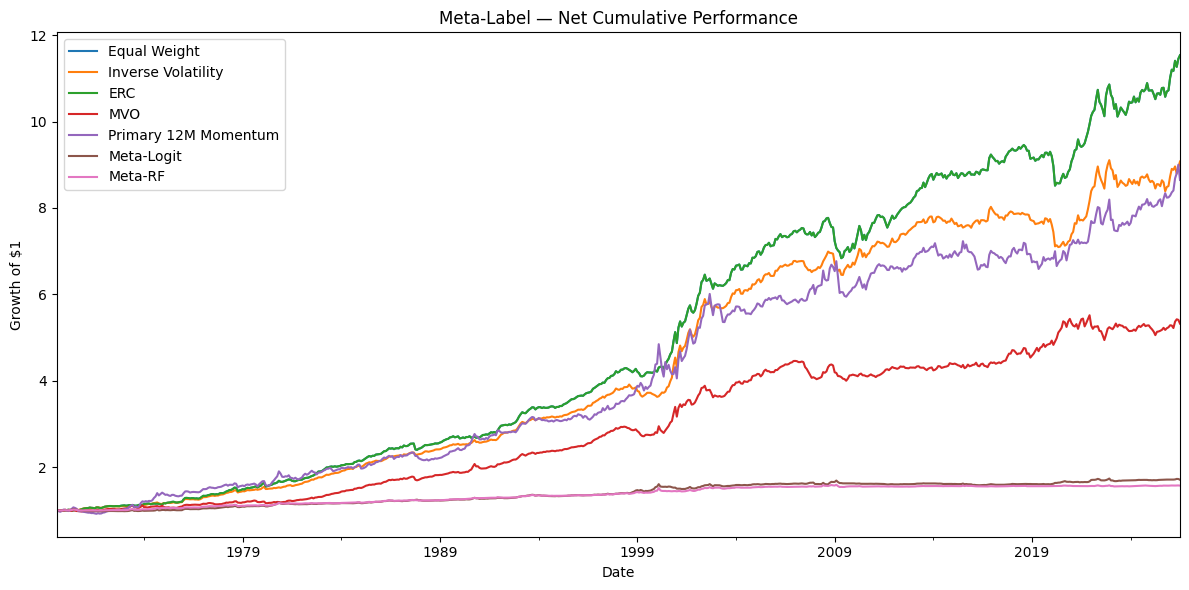

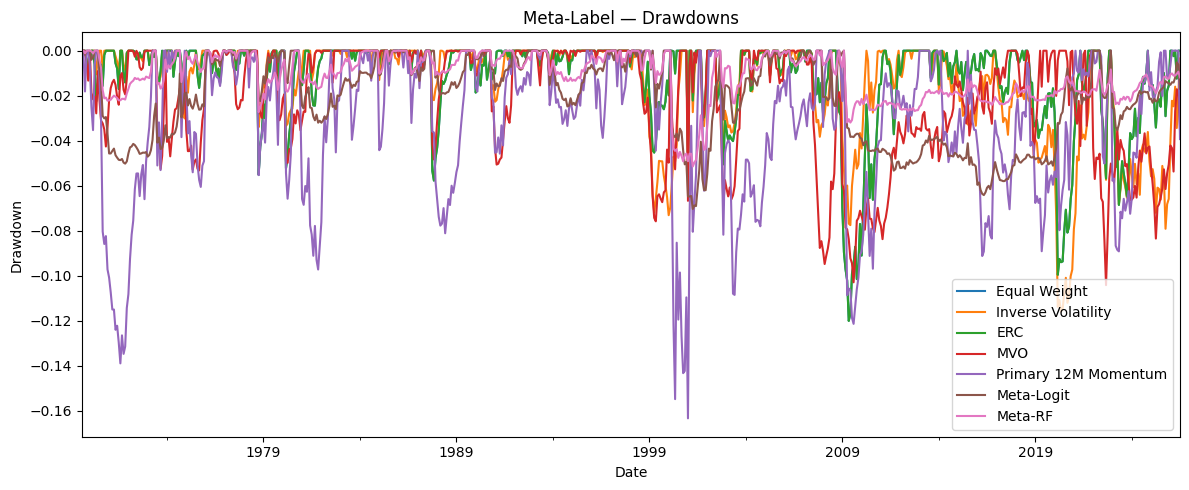

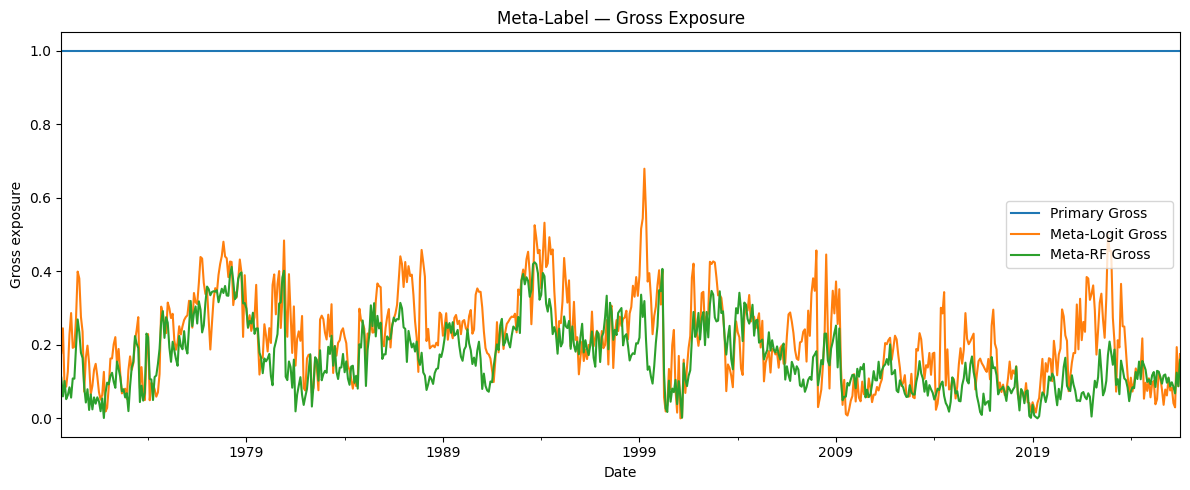

Meta fit failures: 0


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits
from IPython.display import display
from scipy.optimize import minimize
from scipy.stats import skew
from sklearn.covariance import LedoitWolf
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import brier_score_loss, roc_auc_score


# ============================================================
# SETTINGS
# ============================================================

WINDOW_YEARS = 5
MIN_COVERAGE = 0.90
MONTH_COVERAGE = 0.95
MIN_MONTH_OBS = 15

META_TRAIN_MONTHS = 60
PRIMARY_LOOKBACK = 12
MIN_FEATURE_LOOKBACK = 13
LOGIT_C = 1.0
RF_TREES = 300
RF_DEPTH = 3
RF_MIN_LEAF = 10
N_JOBS = min(4, os.cpu_count() or 1)
RF_N_JOBS = 1

COST_BPS = 10
GROSS_LIMIT = 1.0

N_BOOT = 5000
BOOT_BLOCK = 6
SEED = 42

STRATEGIES = [
    "Equal Weight",
    "Inverse Volatility",
    "ERC",
    "MVO",
    "Primary 12M Momentum",
    "Meta-Logit",
    "Meta-RF"
]

print(f"CPU cores: {os.cpu_count()} | Parallel workers: {N_JOBS}")


# ============================================================
# HELPERS / BENCHMARK PORTFOLIOS
# ============================================================

def normalize_long(w):
    w = np.maximum(np.asarray(w, float), 0)
    s = w.sum()
    return w / s if np.isfinite(s) and s > 1e-12 else np.ones(len(w)) / len(w)


def normalize_gross(w, gross=GROSS_LIMIT):
    w = np.asarray(w, float)
    g = np.abs(w).sum()
    return gross * w / g if np.isfinite(g) and g > 1e-12 else np.zeros_like(w)


def trailing_moments(X):
    X = np.asarray(X, float)
    return X.mean(axis=0), LedoitWolf().fit(X).covariance_


def equal_weights(n):
    return np.ones(n) / n


def iv_weights(Sigma):
    vol = np.sqrt(np.maximum(np.diag(Sigma), 1e-12))
    return normalize_long(1 / vol)


def mvo_weights(mu, Sigma):
    mu = np.asarray(mu, float)
    Sigma = np.asarray(Sigma, float) + 1e-10 * np.eye(len(mu))
    try:
        z = np.linalg.solve(Sigma, mu)
    except np.linalg.LinAlgError:
        z = np.linalg.pinv(Sigma) @ mu
    return normalize_gross(z)


def erc_weights(Sigma):
    Sigma = np.asarray(Sigma, float)
    n = len(Sigma)

    def objective(w):
        rc = w * (Sigma @ w)
        return ((rc - rc.mean()) ** 2).sum()

    result = minimize(
        objective,
        np.ones(n) / n,
        method="SLSQP",
        bounds=[(1e-8, 1.0)] * n,
        constraints={"type": "eq", "fun": lambda w: w.sum() - 1},
        options={"maxiter": 1000, "ftol": 1e-12}
    )
    if not result.success:
        raise RuntimeError(f"ERC failed: {result.message}")
    return normalize_long(result.x)


# ============================================================
# DATA
# ============================================================

def prepare_data(ff6, factor_cols):
    raw = ff6[factor_cols].copy().sort_index().astype(float) / 100.0
    raw = raw[~raw.index.duplicated(keep="last")]
    rows = {}

    for period, block in raw.groupby(raw.index.to_period("M")):
        complete = block.dropna(how="any")
        if len(block) == 0 or len(complete) / len(block) < MONTH_COVERAGE or len(complete) < MIN_MONTH_OBS:
            continue
        rows[period] = (1 + complete).prod() - 1

    monthly = pd.DataFrame.from_dict(rows, orient="index").sort_index()
    monthly.index = pd.PeriodIndex(monthly.index, freq="M")
    return raw, monthly


def get_daily_training_window(raw, t):
    start = t - pd.DateOffset(years=WINDOW_YEARS)
    block = raw.loc[(raw.index > start) & (raw.index <= t)]
    if block.empty:
        return None

    valid = block.notna().all(axis=1)
    if valid.mean() < MIN_COVERAGE:
        return None

    train = block.loc[valid]
    return train if len(train) >= int(252 * WINDOW_YEARS * MIN_COVERAGE) else None


# ============================================================
# META FEATURES
# One pooled classifier across factor-month observations.
# All features at month s use information available by s only.
# ============================================================

def rolling_autocorr(r, window=12):
    return r.rolling(window).corr(r.shift(1))


def rolling_avg_corr(monthly, factor, window=12):
    out = pd.Series(np.nan, index=monthly.index, dtype=float)
    others = [c for c in monthly.columns if c != factor]
    if not others:
        return out.fillna(0.0)

    for i in range(window - 1, len(monthly)):
        block = monthly.iloc[i - window + 1:i + 1]
        if block.isna().any(axis=None):
            continue
        corr = block.corr()
        out.iloc[i] = corr.loc[factor, others].mean()
    return out


def build_feature_panels(monthly):
    panels = {}
    mean12_all = monthly.rolling(12).mean()
    vol12_all = monthly.rolling(12).std(ddof=1)
    strength_all = mean12_all / vol12_all.replace(0, np.nan)
    rank_all = strength_all.rank(axis=1, pct=True)

    for factor in monthly.columns:
        r = monthly[factor]
        mean12 = mean12_all[factor]
        vol12 = vol12_all[factor]
        side = np.sign(mean12).replace(0, np.nan)

        X = pd.DataFrame({
            "r1": r,
            "mean3": r.rolling(3).mean(),
            "mean6": r.rolling(6).mean(),
            "mean12": mean12,
            "vol6": r.rolling(6).std(ddof=1),
            "vol12": vol12,
            "autocorr12": rolling_autocorr(r, 12),
            "primary_strength": strength_all[factor],
            "xs_rank_strength": rank_all[factor],
            "avg_corr12": rolling_avg_corr(monthly, factor, 12),
            "side": side
        })

        next_r = r.shift(-1)
        label = pd.Series(np.nan, index=r.index, dtype=float)
        valid = side.notna() & next_r.notna()
        label.loc[valid] = (side.loc[valid] * next_r.loc[valid] > 0).astype(int)

        panels[factor] = {"X": X, "side": side, "next_r": next_r, "label": label}

    return panels


# ============================================================
# META MODELS
# Logistic = linear benchmark; shallow RF = nonlinear meta model.
# ============================================================

def make_logit():
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(C=LOGIT_C, solver="lbfgs", max_iter=1000, random_state=SEED))
    ])


def make_rf():
    return RandomForestClassifier(
        n_estimators=RF_TREES,
        max_depth=RF_DEPTH,
        min_samples_leaf=RF_MIN_LEAF,
        max_features="sqrt",
        bootstrap=True,
        random_state=SEED,
        n_jobs=RF_N_JOBS
    )


# ============================================================
# POOLED ROLLING META INPUTS AT MONTH t
# Training months: t-60,...,t-1, pooled across all factors.
# Feature panels are precomputed once; each task receives only
# its own rolling training/current slices.
# ============================================================

def prepare_meta_inputs(monthly, t, panels):
    train_dates = pd.period_range(end=t - 1, periods=META_TRAIN_MONTHS, freq="M")
    if not train_dates.isin(monthly.index).all():
        raise RuntimeError("Incomplete rolling 60-month Meta window")

    rows = []
    for factor in monthly.columns:
        ds = panels[factor]
        X_train = ds["X"].reindex(train_dates)
        y_train = ds["label"].reindex(train_dates)
        next_train = ds["next_r"].reindex(train_dates)
        if X_train.isna().any(axis=None) or y_train.isna().any() or next_train.isna().any():
            raise RuntimeError(f"{factor}: incomplete pooled Meta training sample")

        block = X_train.copy()
        block["factor"] = factor
        block["label"] = y_train.astype(int).to_numpy()
        block["sample_weight"] = next_train.abs().to_numpy(float)
        rows.append(block)

    pooled = pd.concat(rows, axis=0, ignore_index=True)
    y = pooled.pop("label").astype(int)
    sample_weight = pooled.pop("sample_weight").to_numpy(float)
    if y.nunique() < 2:
        raise RuntimeError("Pooled Meta labels contain only one class")

    mean_sw = sample_weight.mean()
    sample_weight = np.ones_like(sample_weight) if not np.isfinite(mean_sw) or mean_sw <= 1e-12 else sample_weight / mean_sw

    factor_dummies = pd.get_dummies(pooled.pop("factor"), prefix="factor", dtype=float)
    X_train = pd.concat([pooled.reset_index(drop=True), factor_dummies.reset_index(drop=True)], axis=1)

    current_rows, sides = [], {}
    for factor in monthly.columns:
        ds = panels[factor]
        x_now = ds["X"].loc[[t]].copy()
        side_now = ds["side"].loc[t]
        if x_now.isna().any(axis=None) or not np.isfinite(side_now):
            raise RuntimeError(f"{factor}: current Meta inputs unavailable")
        x_now["factor"] = factor
        current_rows.append(x_now)
        sides[factor] = float(side_now)

    current = pd.concat(current_rows, axis=0)
    current_factors = current.pop("factor")
    current_dummies = pd.get_dummies(current_factors, prefix="factor", dtype=float)
    current_dummies = current_dummies.reindex(columns=factor_dummies.columns, fill_value=0.0)
    X_now = pd.concat([current.reset_index(drop=True), current_dummies.reset_index(drop=True)], axis=1)
    X_now = X_now.reindex(columns=X_train.columns, fill_value=0.0)

    return {
        "X_train": X_train.to_numpy(float),
        "y": y.to_numpy(int),
        "sample_weight": sample_weight,
        "X_now": X_now.to_numpy(float),
        "side_vec": np.array([sides[f] for f in monthly.columns], dtype=float)
    }


def fit_meta_inputs(inputs, factor_cols):
    logit = make_logit()
    rf = make_rf()
    logit.fit(inputs["X_train"], inputs["y"], model__sample_weight=inputs["sample_weight"])
    rf.fit(inputs["X_train"], inputs["y"], sample_weight=inputs["sample_weight"])

    p_logit = logit.predict_proba(inputs["X_now"])[:, 1]
    p_rf = rf.predict_proba(inputs["X_now"])[:, 1]
    side_vec = inputs["side_vec"]
    base_w = side_vec / len(factor_cols)
    conf_logit = np.maximum(2 * p_logit - 1, 0.0)
    conf_rf = np.maximum(2 * p_rf - 1, 0.0)

    primary_w = base_w.copy()
    meta_logit_w = base_w * conf_logit
    meta_rf_w = base_w * conf_rf

    for w in (meta_logit_w, meta_rf_w):
        gross = np.abs(w).sum()
        if gross > GROSS_LIMIT + 1e-12:
            w *= GROSS_LIMIT / gross

    sides = dict(zip(factor_cols, side_vec))
    probs_logit = dict(zip(factor_cols, p_logit))
    probs_rf = dict(zip(factor_cols, p_rf))
    active_logit = dict(zip(factor_cols, conf_logit > 0))
    active_rf = dict(zip(factor_cols, conf_rf > 0))
    return primary_w, meta_logit_w, meta_rf_w, probs_logit, probs_rf, sides, active_logit, active_rf


# ============================================================
# ONE INDEPENDENT REBALANCE-DATE FIT
# Model fitting is parallel-safe. Turnover/costs are NOT done here.
# ============================================================

def _fit_one_rebalance(task):
    try:
        with threadpool_limits(limits=1):
            primary_w, logit_w, rf_w, p_logit, p_rf, sides, active_logit, active_rf = fit_meta_inputs(task["meta_inputs"], task["factor_cols"])
            mu, Sigma = trailing_moments(task["train_daily"])
            weights = {
                "Equal Weight": equal_weights(len(task["factor_cols"])),
                "Inverse Volatility": iv_weights(Sigma),
                "ERC": erc_weights(Sigma),
                "MVO": mvo_weights(mu, Sigma),
                "Primary 12M Momentum": primary_w,
                "Meta-Logit": logit_w,
                "Meta-RF": rf_w
            }

        return {
            "success": True,
            "Fit Period": task["fit_period"],
            "Date": task["result_date"],
            "Weights": weights,
            "Realised": task["next_r"],
            "Prob Logit": p_logit,
            "Prob RF": p_rf,
            "Sides": sides,
            "Active Logit": active_logit,
            "Active RF": active_rf,
            "Error": None
        }
    except Exception as e:
        return {
            "success": False,
            "Fit Period": task["fit_period"],
            "Date": task["result_date"],
            "Weights": None,
            "Realised": None,
            "Prob Logit": None,
            "Prob RF": None,
            "Sides": None,
            "Active Logit": None,
            "Active RF": None,
            "Error": repr(e)
        }


# ============================================================
# PARALLEL WALK-FORWARD BACKTEST
# Date-level fitting is parallel; turnover/cost accounting remains
# sequential after sorting fitted dates chronologically.
# ============================================================

def run_meta_comparison(ff6, FACTOR_COLS, n_jobs=N_JOBS):
    raw, monthly = prepare_data(ff6, FACTOR_COLS)
    panels = build_feature_panels(monthly)
    periods = monthly.index.sort_values()
    tasks, failures = [], []

    for i in range(len(periods) - 1):
        t_period, next_period = periods[i], periods[i + 1]
        if i < META_TRAIN_MONTHS + MIN_FEATURE_LOOKBACK - 1 or next_period != t_period + 1:
            continue

        current_daily = raw.loc[raw.index.to_period("M") == t_period]
        if current_daily.empty:
            continue

        t = current_daily.index[-1]
        train_daily = get_daily_training_window(raw, t)
        if train_daily is None:
            continue

        try:
            meta_inputs = prepare_meta_inputs(monthly, t_period, panels)
        except Exception as e:
            failures.append({"Fit Period": t_period, "Fit Date": t_period.to_timestamp("M"), "Error": repr(e)})
            continue

        tasks.append({
            "fit_period": t_period,
            "result_date": next_period.to_timestamp("M"),
            "train_daily": train_daily.to_numpy(float),
            "next_r": monthly.loc[next_period].to_numpy(float),
            "meta_inputs": meta_inputs,
            "factor_cols": list(FACTOR_COLS)
        })

    print(f"Valid Meta rebalance dates: {len(tasks)}")
    if not tasks:
        if failures:
            display(pd.DataFrame(failures))
        raise RuntimeError("No valid Meta OOS dates")

    fitted_all = Parallel(n_jobs=n_jobs, backend="loky", batch_size=1, verbose=5)(delayed(_fit_one_rebalance)(task) for task in tasks)
    failures.extend({"Fit Period": x["Fit Period"], "Fit Date": x["Fit Period"].to_timestamp("M"), "Error": x["Error"]} for x in fitted_all if not x["success"])
    fitted = sorted([x for x in fitted_all if x["success"]], key=lambda x: x["Date"])

    print(f"Successful dates: {len(fitted)} | Failed dates: {len(failures)}")
    if not fitted:
        display(pd.DataFrame(failures))
        raise RuntimeError("All Meta fits failed")

    return_rows, turnover_rows = {}, {}
    prob_logit_rows, prob_rf_rows, hit_rows, exposure_rows = {}, {}, {}, {}
    previous = {name: None for name in STRATEGIES}
    previous_period = None

    for result in fitted:
        t_period = result["Fit Period"]
        if previous_period is None or t_period != previous_period + 1:
            previous = {name: None for name in STRATEGIES}

        weights = result["Weights"]
        next_r = result["Realised"]
        result_date = result["Date"]
        ret_row, turn_row = {}, {}

        for name, w in weights.items():
            w = np.asarray(w, float)
            turnover = 0.0 if previous[name] is None else 0.5 * np.abs(w - previous[name]).sum()
            ret_row[name] = w @ next_r - COST_BPS / 10_000 * turnover
            turn_row[name] = turnover
            previous[name] = w.copy()

        sides = result["Sides"]
        active_logit = result["Active Logit"]
        active_rf = result["Active RF"]
        factor_next = pd.Series(next_r, index=FACTOR_COLS, dtype=float)
        correctness = {f: float(sides[f] * factor_next[f] > 0) for f in FACTOR_COLS}
        selected_logit = [f for f in FACTOR_COLS if active_logit[f]]
        selected_rf = [f for f in FACTOR_COLS if active_rf[f]]

        hit_rows[result_date] = {
            "Primary Hit Rate": np.mean(list(correctness.values())),
            "Logit Selected Hit Rate": np.mean([correctness[f] for f in selected_logit]) if selected_logit else np.nan,
            "Logit Coverage": len(selected_logit) / len(FACTOR_COLS),
            "RF Selected Hit Rate": np.mean([correctness[f] for f in selected_rf]) if selected_rf else np.nan,
            "RF Coverage": len(selected_rf) / len(FACTOR_COLS),
            **{f"PrimaryHit_{f}": correctness[f] for f in FACTOR_COLS},
            **{f"LogitHit_{f}": correctness[f] if active_logit[f] else np.nan for f in FACTOR_COLS},
            **{f"RFHit_{f}": correctness[f] if active_rf[f] else np.nan for f in FACTOR_COLS},
            **{f"LogitSelected_{f}": float(active_logit[f]) for f in FACTOR_COLS},
            **{f"RFSelected_{f}": float(active_rf[f]) for f in FACTOR_COLS}
        }

        hit_primary = weights["Primary 12M Momentum"]
        hit_logit = weights["Meta-Logit"]
        hit_rf = weights["Meta-RF"]
        exposure_rows[result_date] = {
            "Primary Gross": np.abs(hit_primary).sum(),
            "Meta-Logit Gross": np.abs(hit_logit).sum(),
            "Meta-RF Gross": np.abs(hit_rf).sum()
        }

        return_rows[result_date] = ret_row
        turnover_rows[result_date] = turn_row
        prob_logit_rows[result_date] = result["Prob Logit"]
        prob_rf_rows[result_date] = result["Prob RF"]
        previous_period = t_period

    returns = pd.DataFrame.from_dict(return_rows, orient="index").sort_index()
    turnovers = pd.DataFrame.from_dict(turnover_rows, orient="index").sort_index()
    probs_logit = pd.DataFrame.from_dict(prob_logit_rows, orient="index").sort_index()
    probs_rf = pd.DataFrame.from_dict(prob_rf_rows, orient="index").sort_index()
    hits = pd.DataFrame.from_dict(hit_rows, orient="index").sort_index()
    exposures = pd.DataFrame.from_dict(exposure_rows, orient="index").sort_index()

    for df in (returns, turnovers, probs_logit, probs_rf, hits, exposures):
        df.index.name = "Date"

    common = returns.dropna(how="any").index
    return returns.loc[common], turnovers.loc[common], probs_logit.loc[common], probs_rf.loc[common], hits.loc[common], exposures.loc[common], failures, raw, monthly


# ============================================================
# PERFORMANCE / INFERENCE
# ============================================================

def stationary_bootstrap(x, n_boot=N_BOOT, mean_block=BOOT_BLOCK, seed=SEED):
    x = np.asarray(x, float)
    n = len(x)
    rng = np.random.default_rng(seed)
    p = 1 / mean_block
    boot = np.empty((n_boot, n))

    for b in range(n_boot):
        j = rng.integers(n)
        for i in range(n):
            j = rng.integers(n) if i == 0 or rng.random() < p else (j + 1) % n
            boot[b, i] = x[j]
    return boot


def bootstrap_sharpe_ci(r):
    x = pd.Series(r).dropna().to_numpy(float)
    if len(x) < 2:
        return np.nan, np.nan
    boot = stationary_bootstrap(x)
    sd = boot.std(axis=1, ddof=1)
    sr = np.sqrt(12) * boot.mean(axis=1) / sd
    sr = sr[np.isfinite(sr)]
    return np.quantile(sr, [0.025, 0.975]) if len(sr) else (np.nan, np.nan)


def max_drawdown(r):
    wealth = (1 + r).cumprod()
    return (wealth / wealth.cummax() - 1).min()


def performance_table(returns, turnovers):
    rows = []
    for strategy in returns.columns:
        r = returns[strategy].dropna()
        n = len(r)
        sd = r.std(ddof=1)
        terminal = (1 + r).prod()
        lo, hi = bootstrap_sharpe_ci(r)
        rows.append({
            "Strategy": strategy,
            "Arithmetic Return": 12 * r.mean(),
            "Geometric Return": terminal ** (12 / n) - 1 if terminal > 0 else np.nan,
            "Volatility": np.sqrt(12) * sd,
            "Sharpe": np.sqrt(12) * r.mean() / sd if sd > 0 else np.nan,
            "Sharpe CI Low": lo,
            "Sharpe CI High": hi,
            "Skew": skew(r, bias=False),
            "Max Drawdown": max_drawdown(r),
            "Turnover": turnovers.loc[r.index, strategy].mean()
        })
    return pd.DataFrame(rows).set_index("Strategy")


def probability_diagnostics(probabilities, hits, prefix):
    y_true, p = [], []
    for date in probabilities.index:
        for factor in probabilities.columns:
            hit_col = f"PrimaryHit_{factor}"
            if hit_col in hits.columns and np.isfinite(hits.loc[date, hit_col]):
                y_true.append(int(hits.loc[date, hit_col]))
                p.append(float(probabilities.loc[date, factor]))

    if not y_true:
        return pd.Series({"Brier": np.nan, "AUC": np.nan}, name=prefix)

    y_true = np.asarray(y_true, int)
    p = np.asarray(p, float)
    auc = roc_auc_score(y_true, p) if len(np.unique(y_true)) == 2 else np.nan
    return pd.Series({"Brier": brier_score_loss(y_true, p), "AUC": auc}, name=prefix)


# ============================================================
# RUN / OUTPUT
# ============================================================

returns, turnovers, prob_logit, prob_rf, hit_diagnostics, exposure_diagnostics, fit_failures, ff6_decimal, monthly = run_meta_comparison(
    ff6=ff6, FACTOR_COLS=FACTOR_COLS
)
results = performance_table(returns, turnovers)

PERFORMANCE_FORMAT = {
    "Arithmetic Return": "{:.2%}", "Geometric Return": "{:.2%}", "Volatility": "{:.2%}",
    "Sharpe": "{:.2f}", "Sharpe CI Low": "{:.2f}", "Sharpe CI High": "{:.2f}",
    "Skew": "{:.2f}", "Max Drawdown": "{:.2%}", "Turnover": "{:.2%}"
}

display(results.style.format(PERFORMANCE_FORMAT, na_rep="—"))

print("\nMeta model configuration")
meta_spec = pd.DataFrame({
    "Setting": [
        "Primary signal", "Training window", "Training structure", "Features", "Logit", "RF",
        "Observation weights", "Sizing", "Rebalance", "Transaction cost"
    ],
    "Specification": [
        "sign of trailing 12-month mean return",
        "exactly previous 60 labelled months",
        "one pooled model across all factor-month rows",
        "r1, mean3/6/12, vol6/12, autocorr12, primary strength, cross-sectional rank, avg corr12, side + factor dummies",
        f"StandardScaler + L2 LogisticRegression(C={LOGIT_C})",
        f"RandomForest({RF_TREES} trees, depth={RF_DEPTH}, min_leaf={RF_MIN_LEAF}, max_features=sqrt)",
        "|next return|, normalized to mean 1",
        "primary 1/N weight × max(2p-1,0); never gross-normalized upward",
        "monthly",
        f"{COST_BPS} bp × turnover"
    ]
})
display(meta_spec)

print("\nHit-rate diagnostics")
summary_hits = pd.DataFrame({
    "Overall": [
        hit_diagnostics["Primary Hit Rate"].mean(),
        hit_diagnostics["Logit Selected Hit Rate"].mean(),
        hit_diagnostics["Logit Coverage"].mean(),
        hit_diagnostics["RF Selected Hit Rate"].mean(),
        hit_diagnostics["RF Coverage"].mean()
    ]
}, index=["Primary Hit Rate", "Logit Selected Hit Rate", "Logit Coverage", "RF Selected Hit Rate", "RF Coverage"])
display(summary_hits.style.format("{:.2%}"))

per_factor_hits = pd.DataFrame(index=FACTOR_COLS, columns=["Primary Hit Rate", "Logit Selected Hit Rate", "Logit Coverage", "RF Selected Hit Rate", "RF Coverage"], dtype=float)
for factor in FACTOR_COLS:
    per_factor_hits.loc[factor, "Primary Hit Rate"] = hit_diagnostics[f"PrimaryHit_{factor}"].mean()
    per_factor_hits.loc[factor, "Logit Selected Hit Rate"] = hit_diagnostics[f"LogitHit_{factor}"].mean()
    per_factor_hits.loc[factor, "Logit Coverage"] = hit_diagnostics[f"LogitSelected_{factor}"].mean()
    per_factor_hits.loc[factor, "RF Selected Hit Rate"] = hit_diagnostics[f"RFHit_{factor}"].mean()
    per_factor_hits.loc[factor, "RF Coverage"] = hit_diagnostics[f"RFSelected_{factor}"].mean()
print("\nHit rate by factor")
display(per_factor_hits.style.format("{:.2%}"))

prob_quality = pd.concat([
    probability_diagnostics(prob_logit, hit_diagnostics, "Meta-Logit"),
    probability_diagnostics(prob_rf, hit_diagnostics, "Meta-RF")
], axis=1).T
print("\nOOS probability diagnostics")
display(prob_quality.style.format("{:.3f}"))

print("\nGross exposure diagnostics")
display(exposure_diagnostics.describe().T[["mean", "std", "min", "max"]].style.format("{:.3f}"))

print("\nDaily FF6 returns after /100")
display(ff6_decimal.describe().T[["mean", "std", "min", "max"]].style.format("{:.4f}"))
print("\nMonthly FF6 returns")
display(monthly.describe().T[["mean", "std", "min", "max"]].style.format("{:.4f}"))
print("\nStrategy monthly returns")
display(returns.describe().T[["mean", "std", "min", "max"]].style.format("{:.4f}"))
print(f"Common OOS: {returns.index.min().date()} to {returns.index.max().date()} | {len(returns)} months")

wealth = (1 + returns).cumprod()
wealth.plot(figsize=(12, 6), title="Meta-Label — Net Cumulative Performance")
plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

(wealth / wealth.cummax() - 1).plot(figsize=(12, 5), title="Meta-Label — Drawdowns")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

exposure_diagnostics.plot(figsize=(12, 5), title="Meta-Label — Gross Exposure")
plt.ylabel("Gross exposure")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

print(f"Meta fit failures: {len(fit_failures)}")
if fit_failures:
    display(pd.DataFrame(fit_failures)[["Fit Date", "Error"]])
